<a href="https://colab.research.google.com/github/rahafabumwise/instacart-ml-project/blob/main/notebooks/_Data_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Download And Perpare Data

In [ ]:
import kagglehub
import os
import pandas as pd
path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")
files_names = os.listdir(path)
datasets = {}
for file in files_names:
  name = file.removesuffix(".csv")
  datasets[name] = pd.read_csv(f"{path}/{file}")

100%|██████████| 197M/197M [00:02<00:00, 89.6MB/s]

Extracting files...


**Join**

In [ ]:
import numpy as np
import pandas as pd

#Display table sizes within datasets

for k, v in datasets.items():
    print(k, v.shape)

# orders
#Preparing orders and optimizing memory (Memory Optimization)

orders = datasets["orders"]
orders["order_id"] = orders["order_id"].astype("int32")
orders["user_id"] = orders["user_id"].astype("int32")
orders["order_number"] = orders["order_number"].astype("int16")
orders["order_dow"] = orders["order_dow"].astype("int8")
orders["order_hour_of_day"] = orders["order_hour_of_day"].astype("int8")
orders["eval_set"] = orders["eval_set"].astype("category")
orders["days_since_prior_order"] = orders["days_since_prior_order"].astype("float32")

# products
# Preparing products and optimizing memory (Memory Optimization)
products = datasets["products"]
products["product_id"] = products["product_id"].astype("int32")
products["aisle_id"] = products["aisle_id"].astype("int16")
products["department_id"] = products["department_id"].astype("int16")

# aisles
#Preparing aisles and optimizing memory (Memory Optimization)
aisles = datasets["aisles"]
aisles["aisle_id"] = aisles["aisle_id"].astype("int16")

# departments
# Preparing departments and optimizing memory (Memory Optimization)
departments = datasets["departments"]
departments["department_id"] = departments["department_id"].astype("int16")

# order_products_prior ONLY
op_prior = datasets["order_products__prior"]
op_prior["order_id"] = op_prior["order_id"].astype("int32")
op_prior["product_id"] = op_prior["product_id"].astype("int32")
op_prior["add_to_cart_order"] = op_prior["add_to_cart_order"].astype("int16")
op_prior["reordered"] = op_prior["reordered"].astype("int8")


# Product dimension table (products + aisles + departments)
products_enriched = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

products_enriched.head()

#PRIOR full table
prior_full = (
    op_prior
    .merge(orders, on="order_id", how="left")
    .merge(products_enriched, on="product_id", how="left")
)

prior_full.head()

print("prior_full shape:", prior_full.shape)

order_products__train (1384617, 4)
orders (3421083, 7)
aisles (134, 2)
order_products__prior (32434489, 4)
departments (21, 2)
products (49688, 4)
prior_full shape: (32434489, 15)


In [ ]:
datasets["order_products__train"]["order_id"].value_counts()

,count
order_id,
2813632,80
1395075,80
949182,77
2869702,76
341238,76
...,...
1231029,1
1230813,1
2473878,1


In [ ]:
train_with_users = datasets['order_products__train'].merge(datasets['orders'], on="order_id", how="left")

In [ ]:
train_with_users["user_id"].value_counts()

,count
user_id,
149753,80
197541,80
63458,77
83993,76
189951,76
...,...
186787,1
199753,1
51367,1


#Explore the data

I will provide a full description of the data after I join it.

In [ ]:
prior_full.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
       'eval_set', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_name', 'aisle_id', 'department_id',
       'aisle', 'department'],
      dtype='object')

In [ ]:
prior_full.shape

(32434489, 15)

In [ ]:
prior_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   product_id              int32   
 2   add_to_cart_order       int16   
 3   reordered               int8    
 4   user_id                 int32   
 5   eval_set                category
 6   order_number            int16   
 7   order_dow               int8    
 8   order_hour_of_day       int8    
 9   days_since_prior_order  float32 
 10  product_name            object  
 11  aisle_id                int16   
 12  department_id           int16   
 13  aisle                   object  
 14  department              object  
dtypes: category(1), float32(1), int16(4), int32(3), int8(3), object(3)
memory usage: 1.6+ GB


In [ ]:
prior_full.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07,3.035642e+07,3.243449e+07,3.243449e+07
mean,1.710749e+06,2.557634e+04,8.351076e+00,5.896975e-01,1.029372e+05,1.714205e+01,2.738818e+00,1.342498e+01,1.110406e+01,7.121430e+01,9.921906e+00
std,9.873007e+05,1.409669e+04,7.126671e+00,4.918886e-01,5.946648e+04,1.753504e+01,2.090049e+00,4.246365e+00,8.377106e+00,3.820302e+01,6.281156e+00
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,8.559430e+05,1.353000e+04,3.000000e+00,0.000000e+00,5.142100e+04,5.000000e+00,1.000000e+00,1.000000e+01,5.000000e+00,3.100000e+01,4.000000e+00
50%,1.711048e+06,2.525600e+04,6.000000e+00,1.000000e+00,1.026110e+05,1.100000e+01,3.000000e+00,1.300000e+01,8.000000e+00,8.300000e+01,9.000000e+00
75%,2.565514e+06,3.793500e+04,1.100000e+01,1.000000e+00,1.543910e+05,2.400000e+01,5.000000e+00,1.600000e+01,1.500000e+01,1.070000e+02,1.600000e+01
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00,2.062090e+05,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+01,1.340000e+02,2.100000e+01


**Exploratory Data Analysis (EDA)**

In [ ]:
prior_full.keys()

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
       'eval_set', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_name', 'aisle_id', 'department_id',
       'aisle', 'department'],
      dtype='object')

**Missing Values ​​/ NaN**

Here we notice that there is only the days_since_prior_order column.which contains missing values.

In [ ]:
missing = prior_full.isnull().sum()
missing

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,2078068


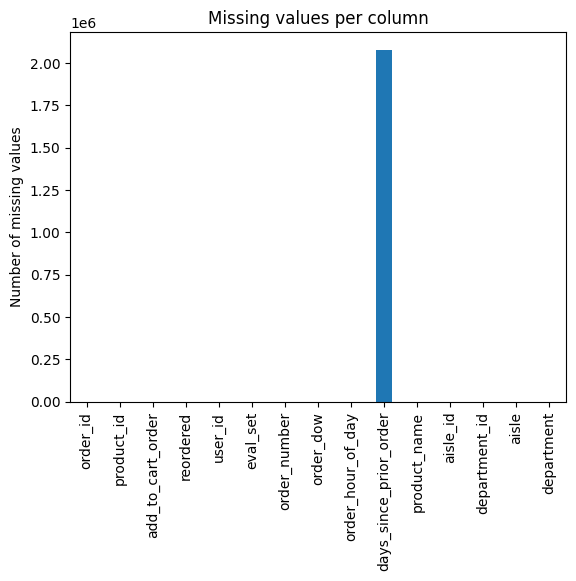

In [ ]:

import matplotlib.pyplot as plt
missing.plot(kind="bar")
plt.ylabel("Number of missing values")
plt.title("Missing values per column")
plt.show()

**Duplicates**

no duplicates in datasets

In [ ]:
prior_full.duplicated().any()

np.False_

**Numerical plots**

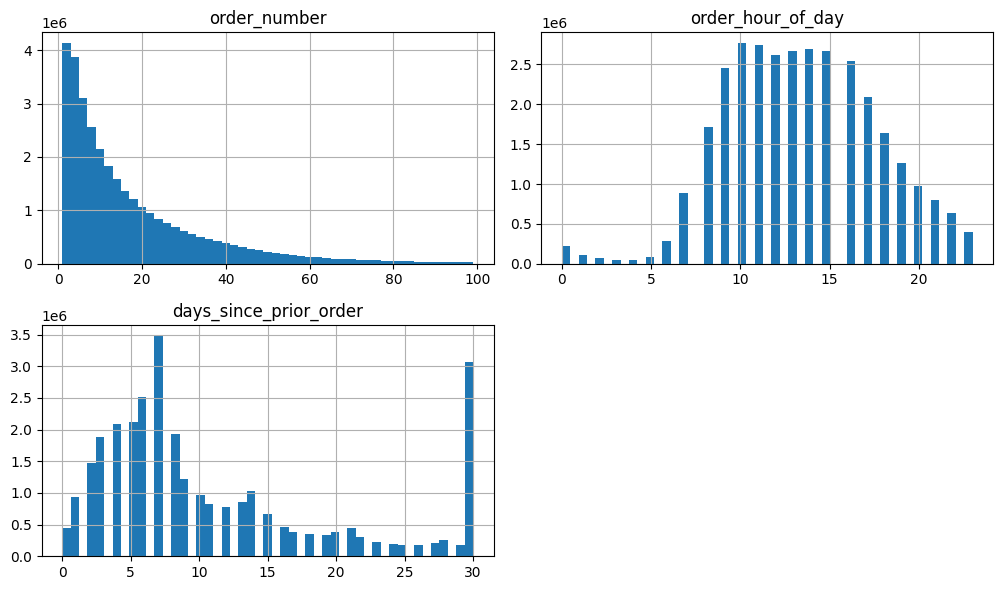

In [ ]:
import matplotlib.pyplot as plt

numeric_columns = ["order_number", "order_hour_of_day", "days_since_prior_order"]
prior_full[numeric_columns].hist(bins=49,figsize=(10,6))
plt.tight_layout()
plt.show()


**Density**

In [ ]:
prior_full[numeric_columns].plot(kind="density", subplots=True, figsize=(10,6))
plt.show()

Sample

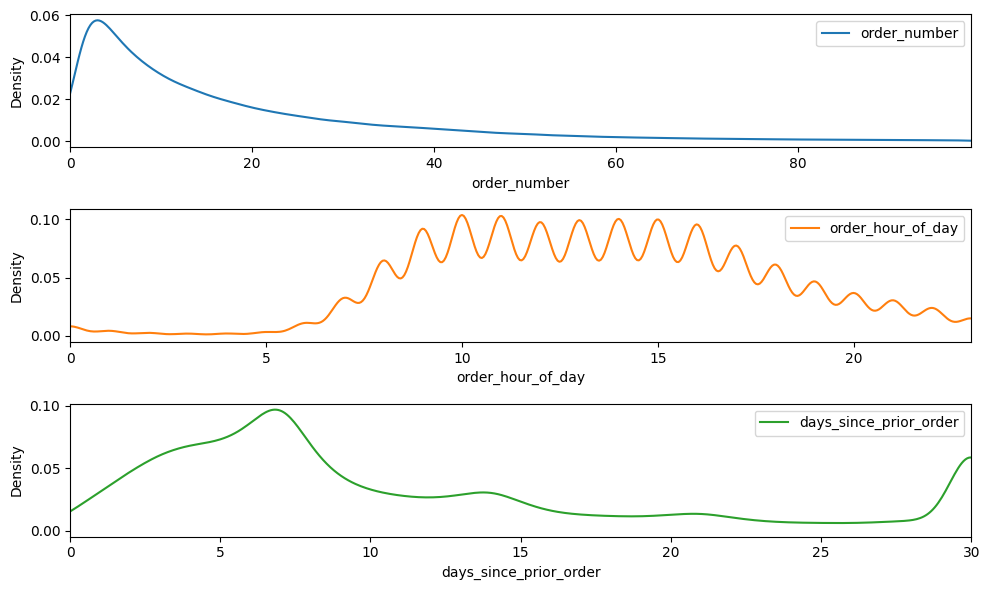

In [ ]:

sample_prior = prior_full[numeric_columns].sample(frac=0.01,random_state=42)

axes = sample_prior.plot(kind="density",subplots=True,figsize=(10,6),sharex=False)

for ax, col in zip(axes, numeric_columns):
    ax.set_xlim(0, sample_prior[col].max())
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


**Cardinality**

Cardinality (number of unique values) per categorical column

In [ ]:
Card_columns = ["eval_set", "department", "aisle"]
cardinality = prior_full[Card_columns].nunique()
print(cardinality)

eval_set        1
department     21
aisle         134
dtype: int64


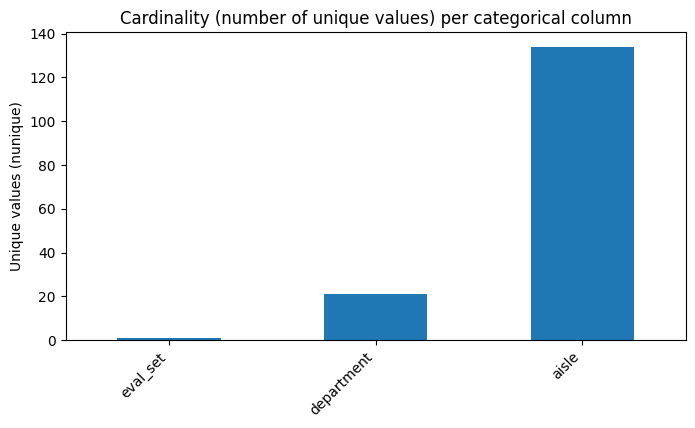

In [ ]:
plt.figure(figsize=(8,4))
cardinality.plot(kind="bar")
plt.title("Cardinality (number of unique values) per categorical column")
plt.ylabel("Unique values (nunique)")
plt.xticks(rotation=45, ha="right")
plt.show()

**Top-k Frequencies**

I found the most frequent values ​​(Top-k) and plotted them using a bar graph.

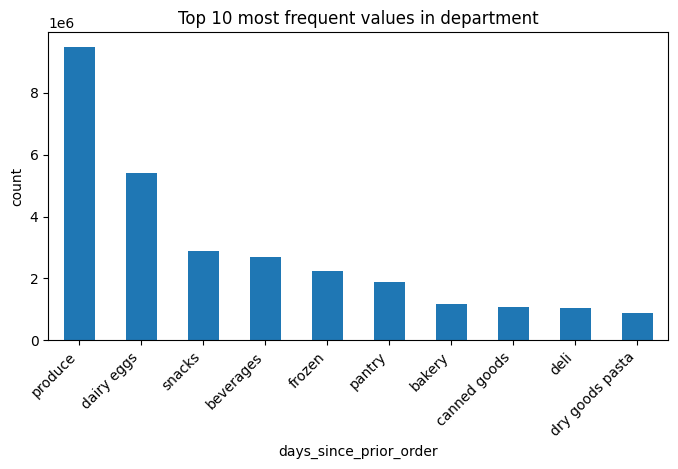

In [ ]:
departments="department"
top_department= prior_full[departments].value_counts().head(10)
plt.figure(figsize=(8,4))
top_department.plot(kind="bar")
plt.title(f"Top 10 most frequent values in {departments}")
plt.ylabel("count")
plt.xlabel(col)
plt.xticks(rotation=45, ha="right")
plt.show()


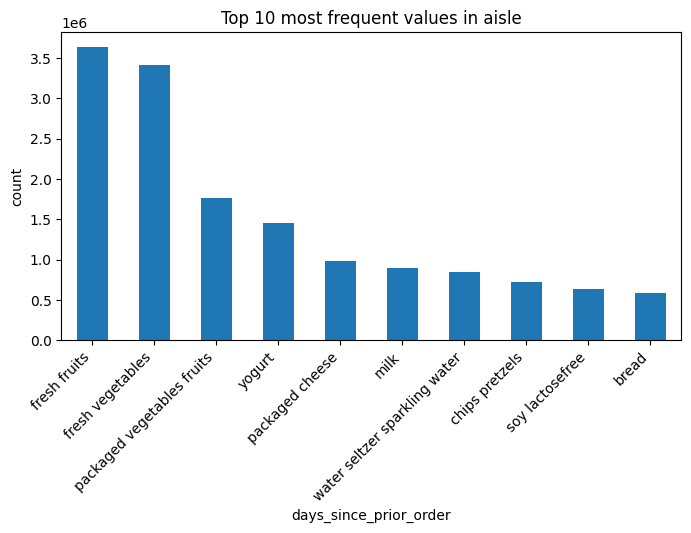

In [ ]:
aisles="aisle"
top_aisle=prior_full["aisle"].value_counts().head(10)
plt.figure(figsize=(8,4))
top_aisle.plot(kind="bar")
plt.title(f"Top 10 most frequent values in {aisles}")
plt.ylabel("count")
plt.xlabel(col)
plt.xticks(rotation=45, ha="right")
plt.show()

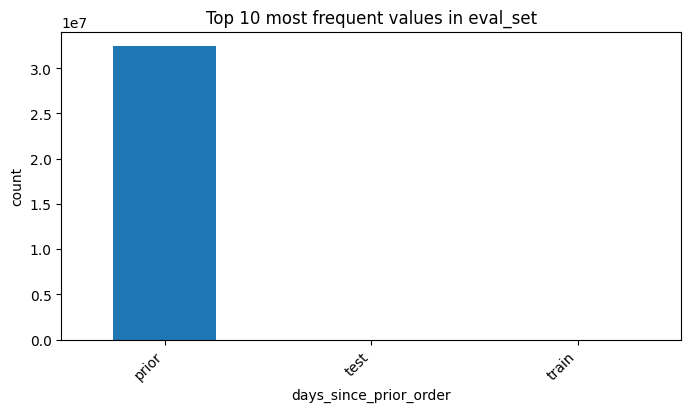

In [ ]:
eval_sets="eval_set"
top_eval_set=prior_full["eval_set"].value_counts().head(10)
plt.figure(figsize=(8,4))
top_eval_set.plot(kind="bar")
plt.title(f"Top 10 most frequent values in {eval_sets}")
plt.ylabel("count")
plt.xlabel(col)
plt.xticks(rotation=45, ha="right")
plt.show()

**Correlation matrix, heatmap and pairwise scatter plots for selected numeric features**

In [ ]:
import numpy as np
num_cols = ["order_number","order_hour_of_day","days_since_prior_order","add_to_cart_order","reordered"]
sample_df = prior_full[num_cols].dropna()
corrilation= sample_df.corr()
print(corrilation)

                        order_number  order_hour_of_day  \
order_number                1.000000          -0.039478   
order_hour_of_day          -0.039478           1.000000   
days_since_prior_order     -0.358422           0.003878   
add_to_cart_order          -0.004921          -0.014972   
reordered                   0.250973          -0.021142   

                        days_since_prior_order  add_to_cart_order  reordered  
order_number                         -0.358422          -0.004921   0.250973  
order_hour_of_day                     0.003878          -0.014972  -0.021142  
days_since_prior_order                1.000000           0.053951  -0.132814  
add_to_cart_order                     0.053951           1.000000  -0.145232  
reordered                            -0.132814          -0.145232   1.000000  


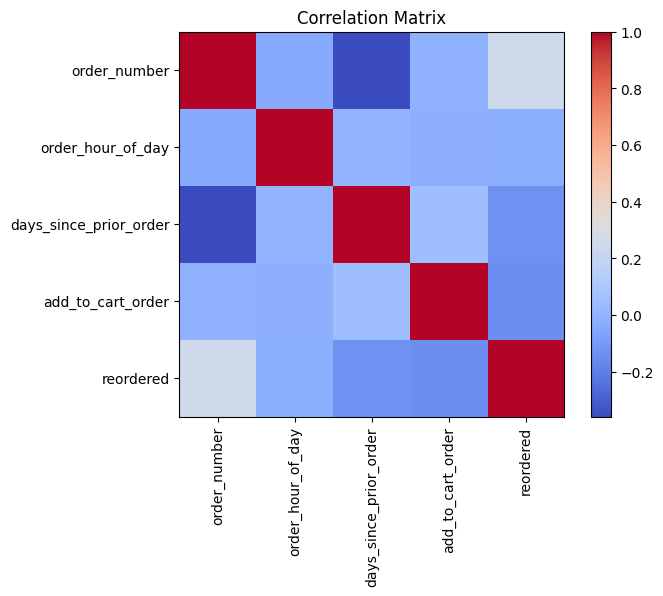

In [ ]:
plt.figure(figsize=(7,5))
corr_matrix = plt.imshow(corrilation, cmap="coolwarm")
plt.colorbar(corr_matrix)
plt.xticks(range(len(corrilation.columns)), corrilation.columns, rotation=90)
plt.yticks(range(len(corrilation.columns)), corrilation.columns)
plt.title("Correlation Matrix")
plt.show()

Here, I'll establish a relationship between just three columns (order_number ,days_since_prior_order ,add_to_cart_order ) to answer these questions:

*Do users with a high order number place orders in fewer days?

→ order_number vs days_since_prior_order

*Does the order in which products are added to the cart affect purchasing behavior?

→ add_to_cart_order vs order_number

*Are products added first more likely to be reordered?



---

**1)** Why does the output look like this?

`days_since_prior_order` has a fixed, discrete value (0 to 30 days only).

While `order_number` increments gradually (1 → 100+).

Each `days` value (e.g., 7 days) is repeated thousands of times \with different order numbers.
There is no clear linear relationship.
Each constant value in days_since_prior_order draws a horizontal line.

Therefore, the shape is now composed of horizontal layers.
This is a recurring time-based behavior (weekly/bi-weekly).

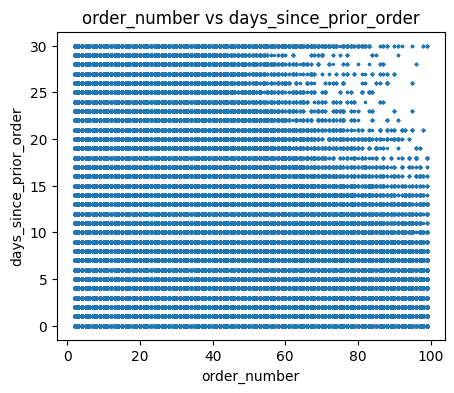

In [ ]:
col1 = "order_number"
col2 = "days_since_prior_order"
col3 = "add_to_cart_order"

corr_3_columns = prior_full[[col1, col2, col3]].dropna()
plt.figure(figsize=(5,4))
plt.scatter(corr_3_columns[col1], corr_3_columns[col2], s=2)
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f"{col1} vs {col2}")
plt.show()



---


**2)** We observe here that the dispersion decreases as the order_number increases.
User behavior becomes more stable over time. Because over time:
Users know what they want,
Requests decrease,
Addition order decreases.

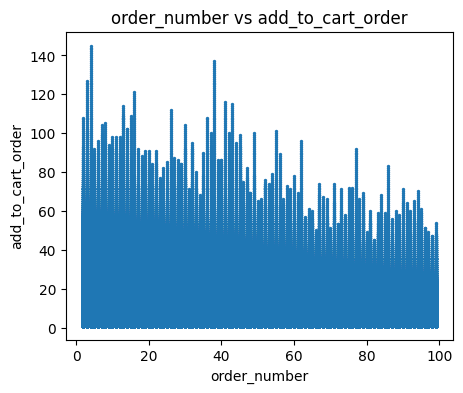

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(corr_3_columns[col1], corr_3_columns[col3], s=2)
plt.xlabel(col1)
plt.ylabel(col3)
plt.title(f"{col1} vs {col3}")
plt.show()



---


**3)** Here, both variables are discrete.
The diagram appears as vertical columns.

This means there isn't a strong, direct relationship, because the waiting time between orders doesn't determine the size or arrangement of the basket.


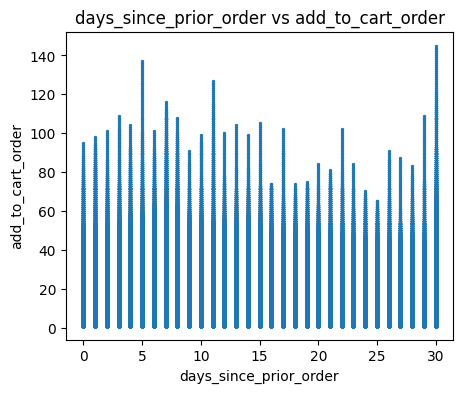

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(corr_3_columns[col2], sample_df[col3], s=2)
plt.xlabel(col2)
plt.ylabel(col3)
plt.title(f"{col2} vs {col3}")
plt.show()

**Time-of-day**

Here I will find the order distribution by hour

In [ ]:
hour_counts = prior_full["order_hour_of_day"].value_counts().sort_index()

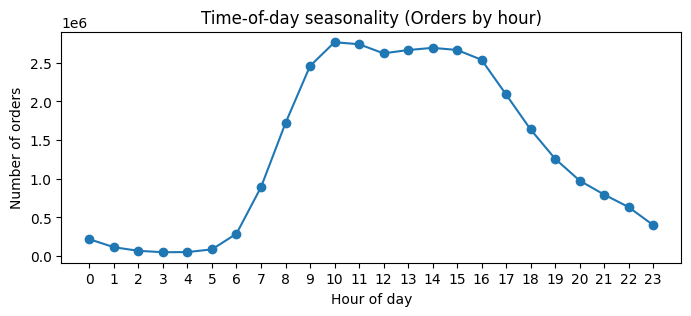

In [ ]:
plt.figure(figsize=(8,3))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.xticks(range(0,24))
plt.title("Time-of-day seasonality (Orders by hour)")
plt.xlabel("Hour of day")
plt.ylabel("Number of orders")
plt.show()

**Day-of-week**

Here I will find the distribution of orders by day

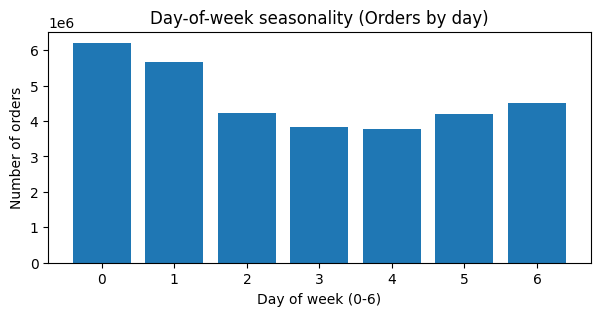

In [ ]:
dow_counts = prior_full["order_dow"].value_counts().sort_index()
plt.figure(figsize=(7,3))
plt.bar(dow_counts.index, dow_counts.values)
plt.title("Day-of-week seasonality (Orders by day)")
plt.xlabel("Day of week (0-6)")
plt.ylabel("Number of orders")
plt.show()

**Monthly seasonality**

There is no actual date in the data, so we make an “approximate” month using days_since_prior_order (cumulative for each user) and then divide by 30.

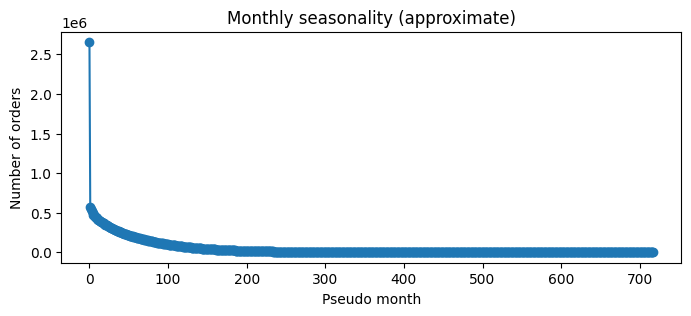

In [ ]:
tmp = prior_full[["user_id", "order_number", "days_since_prior_order"]]
tmp = tmp.sort_values(["user_id", "order_number"])
tmp["days_since_prior_order"] = tmp["days_since_prior_order"].fillna(0)
tmp["days_from_first_order"] = (
    tmp.groupby("user_id")["days_since_prior_order"].cumsum()
)
tmp["pseudo_month"] = (tmp["days_from_first_order"] // 30).astype(int)
month_counts = tmp["pseudo_month"].value_counts().sort_index()
plt.figure(figsize=(8,3))
plt.plot(month_counts.index, month_counts.values, marker="o")
plt.xlabel("Pseudo month")
plt.ylabel("Number of orders")
plt.title("Monthly seasonality (approximate)")
plt.show()

#Feature Engineering

##user features

In [ ]:
prior_full_copy = prior_full.copy()

In [ ]:
###our unique idietifer for these features will be user_id
###total order:The total number of orders placed by each user
user_features = pd.DataFrame({'user_id': prior_full_copy['user_id'].unique()})
user_total = prior_full_copy.groupby('user_id')['order_number'].max().reset_index(name='user_total_orders')

###basket_size_per_order:This feature is used to measure the average basket size for each user, meaning the average number of products a user adds to an order.
basket = prior_full_copy.groupby(['user_id','order_id'])['product_id'].count().reset_index(name='basket_size')
user_avg_basket = basket.groupby('user_id')['basket_size'].mean().reset_index(name='user_average_basket')

###reorder ratio:This feature represents whether a user tends to buy new products or reorder the same products more often.
user_reorder = prior_full_copy.groupby('user_id')['reordered'].mean().reset_index(name='user_reorder_ratio')

###Mean Days Between Orders: This feature represents how many days typically pass between orders for the same user, showing whether the user is a daily, weekly, monthly, or less frequent buyer.
user_days = prior_full_copy.groupby('user_id')['days_since_prior_order'].mean().reset_index(name='user_mean_days_between_order')

### Last Inter-Order Gap: Days between the user’s two most recent prior orders.
user_last_interorder_gap = prior_full_copy.sort_values(['user_id','order_number']).groupby("user_id")["days_since_prior_order"].last().reset_index(name="user_last_interorder_gap")

###merging to user_features
user_features = (user_features
                 .merge(user_total, on='user_id', how='left')
                 .merge(user_avg_basket, on='user_id', how='left')
                 .merge(user_reorder, on='user_id', how='left')
                 .merge(user_days, on='user_id', how='left')
                 .merge(user_last_interorder_gap, on='user_id', how='left'))


In [ ]:
### checking everything is working fine
assert user_features['user_id'].is_unique
user_features.isna().sum().head()

,0
user_id,0
user_total_orders,0
user_average_basket,0
user_reorder_ratio,0
user_mean_days_between_order,0


In [ ]:

user_features.head()

,user_id,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap
0,202279,8,11.250000,0.477778,21.862499,30.0
1,205970,25,12.920000,0.588235,9.805825,7.0
2,178520,56,16.482143,0.884074,6.740659,7.0
3,156122,52,18.596154,0.840745,6.966351,7.0
4,22352,8,11.375000,0.087912,23.670454,30.0


In [ ]:
user_features.shape

(206209, 6)

##product features

In [ ]:
###our unique idietifer for these features will be product_id
product_features = pd.DataFrame({'product_id': prior_full_copy['product_id'].unique()})

######Total Purchases: Number of times the product appears in prior (purchase count).
product_total_purchase = prior_full_copy.groupby('product_id')['order_id'].count().reset_index(name='product_total_purchase')

###Overall Reorder Rate:The proportion of times a product is reordered among all its purchases, indicating how often customers repurchase the product.
product_reorder = prior_full_copy.groupby('product_id')['reordered'].mean().reset_index(name='product_reorder_ratio')

###Average Position in Cart:The average add-to-cart position of a product across orders, reflecting how early or late the product is typically added to the cart.
product_avg_cart_pos = prior_full_copy.groupby('product_id')['add_to_cart_order'].mean().reset_index(name='product_avg_cart_pos')

###Popularity Over Time:A measure of how frequently a product is purchased across different time periods, capturing trends in demand over time.
product_pop_overtime = prior_full_copy.groupby('product_id')['order_number'].mean().reset_index(name='product_pop_overtime')

###merging to product_features
product_features = (product_features
                 .merge(product_total_purchase, on='product_id', how='left')
                 .merge(product_reorder, on='product_id', how='left')
                 .merge(product_avg_cart_pos, on='product_id', how='left')
                 .merge(product_pop_overtime, on='product_id', how='left'))

In [ ]:
### checking everything is working fine
assert product_features['product_id'].is_unique
product_features.isna().sum().head()

,0
product_id,0
product_total_purchase,0
product_reorder_ratio,0
product_avg_cart_pos,0
product_pop_overtime,0


In [ ]:
product_features.head()

,product_id,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime
0,33120,19400,0.708454,6.816959,18.204227
1,28985,67449,0.694465,7.501683,15.959421
2,9327,6299,0.157962,9.943166,14.909351
3,45918,744,0.272849,8.444892,17.795699
4,30035,569,0.507909,8.481547,19.773286


In [ ]:
product_features.shape

(49677, 5)

##UserxProduct features

In [ ]:
###our unique idietifer for these features will be (user_id,product_id)
userxproduct_features = prior_full_copy[["user_id" , "product_id"]].drop_duplicates()

###prior purchase count:How many times a user bought a specific product before.
prior_purchase_count_uxp = prior_full_copy.groupby(["user_id" , "product_id"]).size().reset_index(name="prior_purchase_count_uxp")

###days since last purchase by that user:
tmp = prior_full_copy[['order_id', 'user_id', 'order_number', 'days_since_prior_order',"product_id"]]   # <-- removed .copy()

tmp2 = tmp[["user_id","order_number","days_since_prior_order","order_id"]].drop_duplicates(["user_id","order_id"]).copy()
tmp2["days_since_prior_order"] = tmp2["days_since_prior_order"].fillna(0)
tmp2["cum_col"] = tmp2.sort_values(["user_id","order_number"], kind="mergesort").groupby("user_id")['days_since_prior_order'].cumsum()

# only keep the minimal columns needed for next groupby (huge RAM save)
tmp_min = tmp[["user_id","product_id","order_id"]].copy()
tmp_min = tmp_min.merge(tmp2[["order_id","cum_col"]], on="order_id", how="left")

p_l_p = tmp_min.groupby(["user_id","product_id"])["cum_col"].max().reset_index(name="p_l_p")
u_l_p = tmp2.groupby("user_id")["cum_col"].max().reset_index(name="u_l_p")
l_p = p_l_p.merge(u_l_p, on="user_id", how="left")
l_p["days_since_last"] = l_p['u_l_p'] - l_p['p_l_p']

###average reorder probability for user-product
reorder_prob_userxprod = prior_full_copy.groupby(["user_id", "product_id"])["reordered"].mean().reset_index(name="reorder_prob_userxprod")

###merging to userxproduct_features
userxproduct_features = (userxproduct_features
                 .merge(prior_purchase_count_uxp, on=["user_id" , "product_id"], how='left')
                 .merge(l_p[["user_id", "product_id","days_since_last"]], on=["user_id" , "product_id"], how='left')
                 .merge(reorder_prob_userxprod , on=["user_id" , "product_id"], how='left'))


In [ ]:
import gc

del tmp, tmp2, tmp_min, p_l_p, u_l_p, l_p, prior_purchase_count_uxp, reorder_prob_userxprod,prior_full_copy
gc.collect()

16

In [ ]:
userxproduct_features.sort_values("user_id").head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod
11081338,1,14084,1,176.0,0.000000
3105783,1,10258,9,0.0,0.888889
11111602,1,35951,1,0.0,0.000000
10394404,1,46149,3,0.0,0.666667
10394403,1,49235,2,30.0,0.500000


In [ ]:
userxproduct_features.shape

(13307953, 5)

In [ ]:
userxproduct_features.duplicated().any()

np.False_

In [ ]:
features =( userxproduct_features
                            .merge(user_features, on="user_id", how="left")
                            .merge(product_features, on="product_id", how="left"))

In [ ]:
features.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909351
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444892,17.795699
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481547,19.773286


In [ ]:
features.shape

(13307953, 14)

In [ ]:
features.isna().value_counts()

,,,,,,,,,,,,,,count
user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,13307953


In [ ]:
features.duplicated().any()

np.False_

In [ ]:
features.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909351
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444892,17.795699
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481547,19.773286


##more features for clasification task


In [ ]:
tmp = prior_full[["user_id", "product_id", "order_id", "order_number"]]
# user last prior order_number
u_last = (
    tmp.groupby("user_id")["order_number"]
    .max()
    .reset_index(name="last_prior_ordnum")
)

# rows from last prior order only
last_basket = (
    tmp.merge(u_last, on="user_id", how="left")
)
last_basket = last_basket[last_basket["order_number"] == last_basket["last_prior_ordnum"]]

# unique user-product pairs that appeared in last basket
last_order_contains = (
    last_basket[["user_id", "product_id"]]
    .drop_duplicates()
)
last_order_contains["last_order_contains_product"] = 1
last_order_contains["last_order_contains_product"] = last_order_contains["last_order_contains_product"].astype("int8")
# unique occurrences per order
upo = (
    tmp[["user_id", "product_id", "order_number"]]
    .drop_duplicates()
    .sort_values(["user_id", "product_id", "order_number"])
)

# bring last order number per user
upo = upo.merge(u_last, on="user_id", how="left")

# consecutive check inside each (user, product)
upo["prev_ord"] = upo.groupby(["user_id", "product_id"])["order_number"].shift(1)
upo["is_consecutive"] = (upo["order_number"] == upo["prev_ord"] + 1)

# block id for consecutive runs
upo["block_id"] = (~upo["is_consecutive"]).groupby([upo["user_id"], upo["product_id"]]).cumsum()

# summarize each block (length + max order)
blocks = (
    upo.groupby(["user_id", "product_id", "block_id"])
    .agg(
        block_len=("order_number", "size"),
        block_max=("order_number", "max"),
        last_prior_ordnum=("last_prior_ordnum", "max"),
    )
    .reset_index()
)

# keep only the block that ends at last_prior_ordnum
streak = blocks[blocks["block_max"] == blocks["last_prior_ordnum"]][["user_id", "product_id", "block_len"]]
streak = streak.rename(columns={"block_len": "streak"})
streak["streak"] = streak["streak"].astype("int16")
uxp_last_streak = last_order_contains.merge(streak, on=["user_id", "product_id"], how="outer")

# fill missing: if not in last basket -> 0 ; if no streak -> 0
uxp_last_streak["last_order_contains_product"] = uxp_last_streak["last_order_contains_product"].fillna(0).astype("int8")
uxp_last_streak["streak"] = uxp_last_streak["streak"].fillna(0).astype("int16")


In [ ]:
import gc

for name in ["u_last", "tmp", "last_basket", "last_order_contains", "upo", "blocks", "streak"]:
    if name in globals():
        del globals()[name]

gc.collect()


7

In [ ]:
uxp_last_streak.isna().sum()

,0
user_id,0
product_id,0
last_order_contains_product,0
streak,0


##saving to google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================
# Save engineered feature tables
# ============================

import os

BASE_PATH = "/content/drive/MyDrive/instacart_project/data/features"
os.makedirs(BASE_PATH, exist_ok=True)

user_features.to_parquet(
    f"{BASE_PATH}/user_features.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)

product_features.to_parquet(
    f"{BASE_PATH}/product_features.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)

userxproduct_features.to_parquet(
    f"{BASE_PATH}/uxp_features.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)

uxp_last_streak.to_parquet(
    f"{BASE_PATH}/uxp_last_streak.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)

print("Feature tables saved successfully.")



Feature tables saved successfully.


#Classification Task

##creating the dataframe

In [ ]:
user_product_train = datasets['order_products__train'].merge(datasets["orders"], on="order_id", how="left")

In [ ]:
user_product_train.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,49302,1,1,112108,train,4,4,10,9.0
1,1,11109,2,1,112108,train,4,4,10,9.0
2,1,10246,3,0,112108,train,4,4,10,9.0
3,1,49683,4,0,112108,train,4,4,10,9.0
4,1,43633,5,1,112108,train,4,4,10,9.0


In [ ]:
train_pairs = user_product_train[["user_id","product_id"]].drop_duplicates()

In [ ]:
train_pairs.head()

,user_id,product_id
0,112108,49302
1,112108,11109
2,112108,10246
3,112108,49683
4,112108,43633


In [ ]:
train_pairs.shape

(1384617, 2)

In [ ]:
train_pairs["reorder"] = 1

In [ ]:
train_pairs.head()

,user_id,product_id,reorder
0,112108,49302,1
1,112108,11109,1
2,112108,10246,1
3,112108,49683,1
4,112108,43633,1


In [ ]:
cla_df = features.merge(train_pairs, on=["user_id", "product_id"], how="left")

In [ ]:
cla_df.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227,1.0
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421,NaN
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909351,NaN
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444892,17.795699,NaN
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481547,19.773286,NaN


In [ ]:
cla_df.isna().sum()

,0
user_id,0
product_id,0
prior_purchase_count_uxp,0
days_since_last,0
reorder_prob_userxprod,0
user_total_orders,0
user_average_basket,0
user_reorder_ratio,0
user_mean_days_between_order,0
user_last_interorder_gap,0


In [ ]:
prior_pairs = features[["user_id","product_id"]].drop_duplicates()
train_pairs = user_product_train[["user_id","product_id"]].drop_duplicates()

overlap = prior_pairs.merge(train_pairs, on=["user_id","product_id"], how="inner")

print("prior pairs:", len(prior_pairs))
print("train pairs:", len(train_pairs))
print("overlap:", len(overlap))
print("overlap rate vs prior:", len(overlap)/len(prior_pairs))
print("overlap rate vs train:", len(overlap)/len(train_pairs))


prior pairs: 13307953
train pairs: 1384617
overlap: 828824
overlap rate vs prior: 0.062280352207435656
overlap rate vs train: 0.5985944127509629


In [ ]:
import gc

for name in ["prior_pairs", "train_pairs", "overlap"]:
    if name in globals():
        del globals()[name]

gc.collect()


0

In [ ]:
cla_df["reorder"] = cla_df["reorder"].fillna(0).astype("int8")

In [ ]:
cla_df.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227,1
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421,0
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909351,0
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444892,17.795699,0
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481547,19.773286,0


In [ ]:
cla_df.isna().sum()

,0
user_id,0
product_id,0
prior_purchase_count_uxp,0
days_since_last,0
reorder_prob_userxprod,0
user_total_orders,0
user_average_basket,0
user_reorder_ratio,0
user_mean_days_between_order,0
user_last_interorder_gap,0


the label is imblanced, 12 million  product x user does not appear in train and only 800k appreared

In [ ]:
cla_df["reorder"].value_counts()

,count
reorder,
0,12479129
1,828824


##adding new features + saving the df to google drive

In [ ]:
cla_df = cla_df.merge(uxp_last_streak[["user_id","product_id","streak","last_order_contains_product"]],
                      on=["user_id","product_id"], how="left")
cla_df[["streak","last_order_contains_product"]] = cla_df[["streak","last_order_contains_product"]].fillna(0)


In [ ]:
import pandas as pd
import numpy as np
import os

def optimize_df(df: pd.DataFrame, cat_ratio: float = 0.5) -> pd.DataFrame:
    """
    Downcast numeric dtypes + optionally convert object columns to category
    if they are low-cardinality (nunique/len <= cat_ratio).
    """
    df = df.copy()

    # 1) Downcast integers
    int_cols = df.select_dtypes(include=["int64", "int32", "int16", "int8", "uint64", "uint32", "uint16", "uint8"]).columns
    for c in int_cols:
        df[c] = pd.to_numeric(df[c], downcast="integer")

    # 2) Downcast floats
    float_cols = df.select_dtypes(include=["float64", "float32"]).columns
    for c in float_cols:
        df[c] = pd.to_numeric(df[c], downcast="float")  # usually -> float32

    # 3) Convert object columns to category if low-cardinality
    obj_cols = df.select_dtypes(include=["object"]).columns
    n = len(df)
    for c in obj_cols:
        nunique = df[c].nunique(dropna=True)
        if n > 0 and (nunique / n) <= cat_ratio:
            df[c] = df[c].astype("category")

    return df


# ====== optimize whole clf_df ======
clf_df_opt = optimize_df(cla_df, cat_ratio=0.5)

# (Optional but recommended) force your two new cols to tiny ints
# if you already filled NaNs with 0, this is safe:
if "last_order_contains_product" in clf_df_opt.columns:
    clf_df_opt["last_order_contains_product"] = clf_df_opt["last_order_contains_product"].astype("int8")
if "streak" in clf_df_opt.columns:
    clf_df_opt["streak"] = clf_df_opt["streak"].astype("int16")

# ====== save to Drive ======
out_dir = "/content/drive/MyDrive/instacart_project/data/classification"
os.makedirs(out_dir, exist_ok=True)

out_path = f"{out_dir}/clf_df.parquet"
clf_df_opt.to_parquet(out_path, index=False, engine="pyarrow", compression="snappy")

print("✅ Saved optimized clf_df to:", out_path)
print("Shape:", clf_df_opt.shape)
print("Memory (MB):", round(clf_df_opt.memory_usage(deep=True).sum() / 1024**2, 2))


✅ Saved optimized clf_df to: /content/drive/MyDrive/instacart_project/data/classification/clf_df.parquet
Shape: (13307953, 17)
Memory (MB): 685.34


##IMPOOORTANTTT NOTEE!!!

Recommendation: After running the save-to-Drive cells, it is strongly recommended to close and reopen the notebook to start with a fresh RAM state. This is because all subsequent classification tasks do not require any of the previously executed cells, as all necessary data has already been saved to Google Drive.

Additional note: If you wish, you may also run the regression save cells before closing the notebook. However, please make sure not to run any further classification cells before restarting the notebook.

##EDA for Clasification df

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
clf_data = pd.read_parquet("/content/drive/MyDrive/instacart_project/data/classification/clf_df.parquet")

In [ ]:
clf_data.shape

(13307953, 17)

In [ ]:
clf_data.columns

Index(['user_id', 'product_id', 'prior_purchase_count_uxp', 'days_since_last',
       'reorder_prob_userxprod', 'user_total_orders', 'user_average_basket',
       'user_reorder_ratio', 'user_mean_days_between_order',
       'user_last_interorder_gap', 'product_total_purchase',
       'product_reorder_ratio', 'product_avg_cart_pos', 'product_pop_overtime',
       'reorder', 'streak', 'last_order_contains_product'],
      dtype='object')

In [ ]:
clf_data.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227,1,1,1
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421,0,0,0
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909350,0,0,0
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444893,17.795698,0,0,0
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481546,19.773287,0,0,0


In [ ]:
clf_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13307953 entries, 0 to 13307952
Data columns (total 17 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   user_id                       int32  
 1   product_id                    int32  
 2   prior_purchase_count_uxp      int8   
 3   days_since_last               float32
 4   reorder_prob_userxprod        float32
 5   user_total_orders             int8   
 6   user_average_basket           float32
 7   user_reorder_ratio            float32
 8   user_mean_days_between_order  float32
 9   user_last_interorder_gap      float32
 10  product_total_purchase        int32  
 11  product_reorder_ratio         float32
 12  product_avg_cart_pos          float32
 13  product_pop_overtime          float32
 14  reorder                       int8   
 15  streak                        int16  
 16  last_order_contains_product   int8   
dtypes: float32(9), int16(1), int32(3), int8(4)
memory usage: 685.3 

In [ ]:
clf_data.describe()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
count,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07
mean,1.029987e+05,2.551351e+04,2.437226e+00,8.358693e+01,2.655046e-01,2.538019e+01,1.270054e+01,5.015150e-01,1.300562e+01,1.359757e+01,2.249905e+04,5.345428e-01,8.724360e+00,1.674496e+01,6.228035e-02,2.700782e-01,1.607902e-01
std,5.943677e+04,1.422429e+04,3.554528e+00,8.576776e+01,3.636101e-01,2.228080e+01,6.232091e+00,1.960039e-01,6.465785e+00,9.732783e+00,5.587238e+04,1.610382e-01,1.597422e+00,3.027325e+00,2.416641e-01,9.786898e-01,3.673373e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.157900e+04,1.329200e+04,1.000000e+00,1.400000e+01,0.000000e+00,9.000000e+00,8.250000e+00,3.577982e-01,7.812000e+00,6.000000e+00,1.050000e+03,4.418605e-01,7.935209e+00,1.487410e+01,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.027130e+05,2.564000e+04,1.000000e+00,5.500000e+01,0.000000e+00,1.800000e+01,1.153333e+01,5.182927e-01,1.176596e+01,1.000000e+01,4.306000e+03,5.596828e-01,8.932644e+00,1.704964e+01,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.544500e+05,3.815700e+04,2.000000e+00,1.300000e+02,5.000000e-01,3.500000e+01,1.592857e+01,6.576200e-01,1.725000e+01,2.200000e+01,1.643900e+04,6.518007e-01,9.751692e+00,1.860433e+01,0.000000e+00,0.000000e+00,0.000000e+00
max,2.062090e+05,4.968800e+04,9.900000e+01,3.650000e+02,9.898990e-01,9.900000e+01,7.025000e+01,9.895288e-01,3.000000e+01,3.000000e+01,4.725650e+05,9.411765e-01,5.300000e+01,6.380000e+01,1.000000e+00,9.900000e+01,1.000000e+00


In [ ]:
clf_data.isna().sum()

,0
user_id,0
product_id,0
prior_purchase_count_uxp,0
days_since_last,0
reorder_prob_userxprod,0
user_total_orders,0
user_average_basket,0
user_reorder_ratio,0
user_mean_days_between_order,0
user_last_interorder_gap,0


In [ ]:
clf_data.duplicated().sum()

np.int64(0)

no more EDA until i split my data

###split my data

We performed a group split by user_id so that each user appears in only one set. To maintain label balance, we stratified users using a user-level summary label and verified that both row-level and user-level reorder rates match across train and test

In [ ]:
user_label = clf_data.groupby("user_id")["reorder"].max().astype(int)

In [ ]:
user_label.value_counts()

,count
reorder,
1,122607
0,83602


In [ ]:
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

train_users, test_users = train_test_split(
    users,
    test_size=0.2,
    random_state=42,
    stratify=y_user
)

In [ ]:
cl_train_df = clf_data[clf_data["user_id"].isin(train_users)].copy()
cl_test_df  = clf_data[clf_data["user_id"].isin(test_users)].copy()

In [ ]:
# 1) No overlap in users
assert set(cl_train_df["user_id"]).isdisjoint(set(cl_test_df["user_id"]))

# 2) Distribution check (row-level)
print("Row reorder rate - train:", cl_train_df["reorder"].mean())
print("Row reorder rate - test :", cl_test_df["reorder"].mean())

# 3) Distribution check (user-level)
print("User reorder rate - train:", user_label.loc[train_users].mean())
print("User reorder rate - test :", user_label.loc[test_users].mean())


Row reorder rate - train: 0.06228055421132008
Row reorder rate - test : 0.062279545787892056
User reorder rate - train: 0.5945734601465748
User reorder rate - test : 0.594588041317104


###back to EDA

In [ ]:
cl_train_df.shape

(10642150, 17)

In [ ]:
cl_train_df.corr()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
user_id,1.000000,-0.000309,-0.001349,-0.001294,-0.001583,-0.006805,0.000620,-0.004796,0.004427,0.004284,-0.000379,-0.000982,-0.001156,-0.003867,-0.000239,-0.000336,0.000164
product_id,-0.000309,1.000000,0.002952,-0.003670,0.008373,-0.002671,0.004069,-0.002047,0.001395,0.001237,0.034790,0.025288,0.002867,0.000297,0.002082,-0.000563,0.001328
prior_purchase_count_uxp,-0.001349,0.002952,1.000000,-0.193002,0.655283,0.235513,0.053277,0.306107,-0.171425,-0.114707,0.163946,0.233017,-0.163577,0.089599,0.193079,0.345851,0.182896
days_since_last,-0.001294,-0.003670,-0.193002,1.000000,-0.231026,0.317746,-0.032857,0.268547,-0.154841,-0.057170,-0.090236,-0.108644,0.087725,-0.058053,-0.172738,-0.267438,-0.424939
reorder_prob_userxprod,-0.001583,0.008373,0.655283,-0.231026,1.000000,0.188838,0.071529,0.329999,-0.153980,-0.101710,0.165960,0.287110,-0.165300,0.089396,0.193437,0.253336,0.192311
user_total_orders,-0.006805,-0.002671,0.235513,0.317746,0.188838,1.000000,-0.081311,0.668485,-0.666528,-0.450414,-0.033664,-0.033060,0.065152,0.115327,-0.072905,-0.098485,-0.182934
user_average_basket,0.000620,0.004069,0.053277,-0.032857,0.071529,-0.081311,1.000000,0.162771,0.085356,0.043209,-0.023108,-0.018992,0.163351,0.010455,0.037853,0.046234,0.044015
user_reorder_ratio,-0.004796,-0.002047,0.306107,0.268547,0.329999,0.668485,0.162771,1.000000,-0.544078,-0.354527,-0.001220,0.037292,0.029503,0.132977,0.004730,0.002486,-0.118461
user_mean_days_between_order,0.004427,0.001395,-0.171425,-0.154841,-0.153980,-0.666528,0.085356,-0.544078,1.000000,0.622951,0.028207,0.034392,-0.065470,-0.094582,0.055373,0.080528,0.161266
user_last_interorder_gap,0.004284,0.001237,-0.114707,-0.057170,-0.101710,-0.450414,0.043209,-0.354527,0.622951,1.000000,0.016489,0.019286,-0.045066,-0.081978,0.028841,0.054102,0.112763


In [ ]:
cl_train_df.corr()["reorder"]

,reorder
user_id,-0.000239
product_id,0.002082
prior_purchase_count_uxp,0.193079
days_since_last,-0.172738
reorder_prob_userxprod,0.193437
user_total_orders,-0.072905
user_average_basket,0.037853
user_reorder_ratio,0.004730
user_mean_days_between_order,0.055373
user_last_interorder_gap,0.028841


In [ ]:
from sklearn.model_selection import train_test_split

eda_df, _ = train_test_split(cl_train_df, train_size=0.03, stratify=cl_train_df["reorder"], random_state=42)

In [ ]:
cl_train_df["reorder"].value_counts(normalize=True), \
eda_df["reorder"].value_counts(normalize=True)

(reorder
 0    0.937719
 1    0.062281
 Name: proportion, dtype: float64,
 reorder
 0    0.937719
 1    0.062281
 Name: proportion, dtype: float64)

In [ ]:
eda_df

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
5285684,34928,47788,2,207.0,0.500000,12,6.166667,0.567568,21.430769,9.0,8291,0.578097,8.782414,19.594742,0,0,0
11844201,118004,421,1,44.0,0.000000,4,9.500000,0.157895,21.678572,30.0,528,0.346591,10.123106,16.361742,0,0,0
12051587,168020,48006,1,49.0,0.000000,10,11.000000,0.490909,6.850000,8.0,100,0.390000,12.010000,13.510000,0,0,0
1824649,118084,5259,1,0.0,0.000000,3,10.333333,0.032258,30.000000,30.0,994,0.428571,9.060362,12.536218,0,1,1
3247943,29089,12000,7,118.0,0.857143,54,22.074074,0.847315,5.953072,5.0,1166,0.595197,10.908234,22.424528,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2959599,8228,47209,6,28.0,0.833333,26,13.384615,0.586207,12.753709,18.0,213584,0.796553,6.775011,19.420443,0,0,0
8053480,131859,38293,2,30.0,0.500000,4,9.750000,0.282051,29.608696,30.0,26721,0.642903,8.925639,16.733131,0,0,0
11594218,166968,45345,1,176.0,0.000000,38,11.026316,0.711217,10.174757,17.0,649,0.329738,10.466872,16.959938,0,0,0
1863285,2877,4421,1,215.0,0.000000,13,17.923077,0.510730,20.683035,30.0,12230,0.547915,9.776043,16.322731,0,0,0


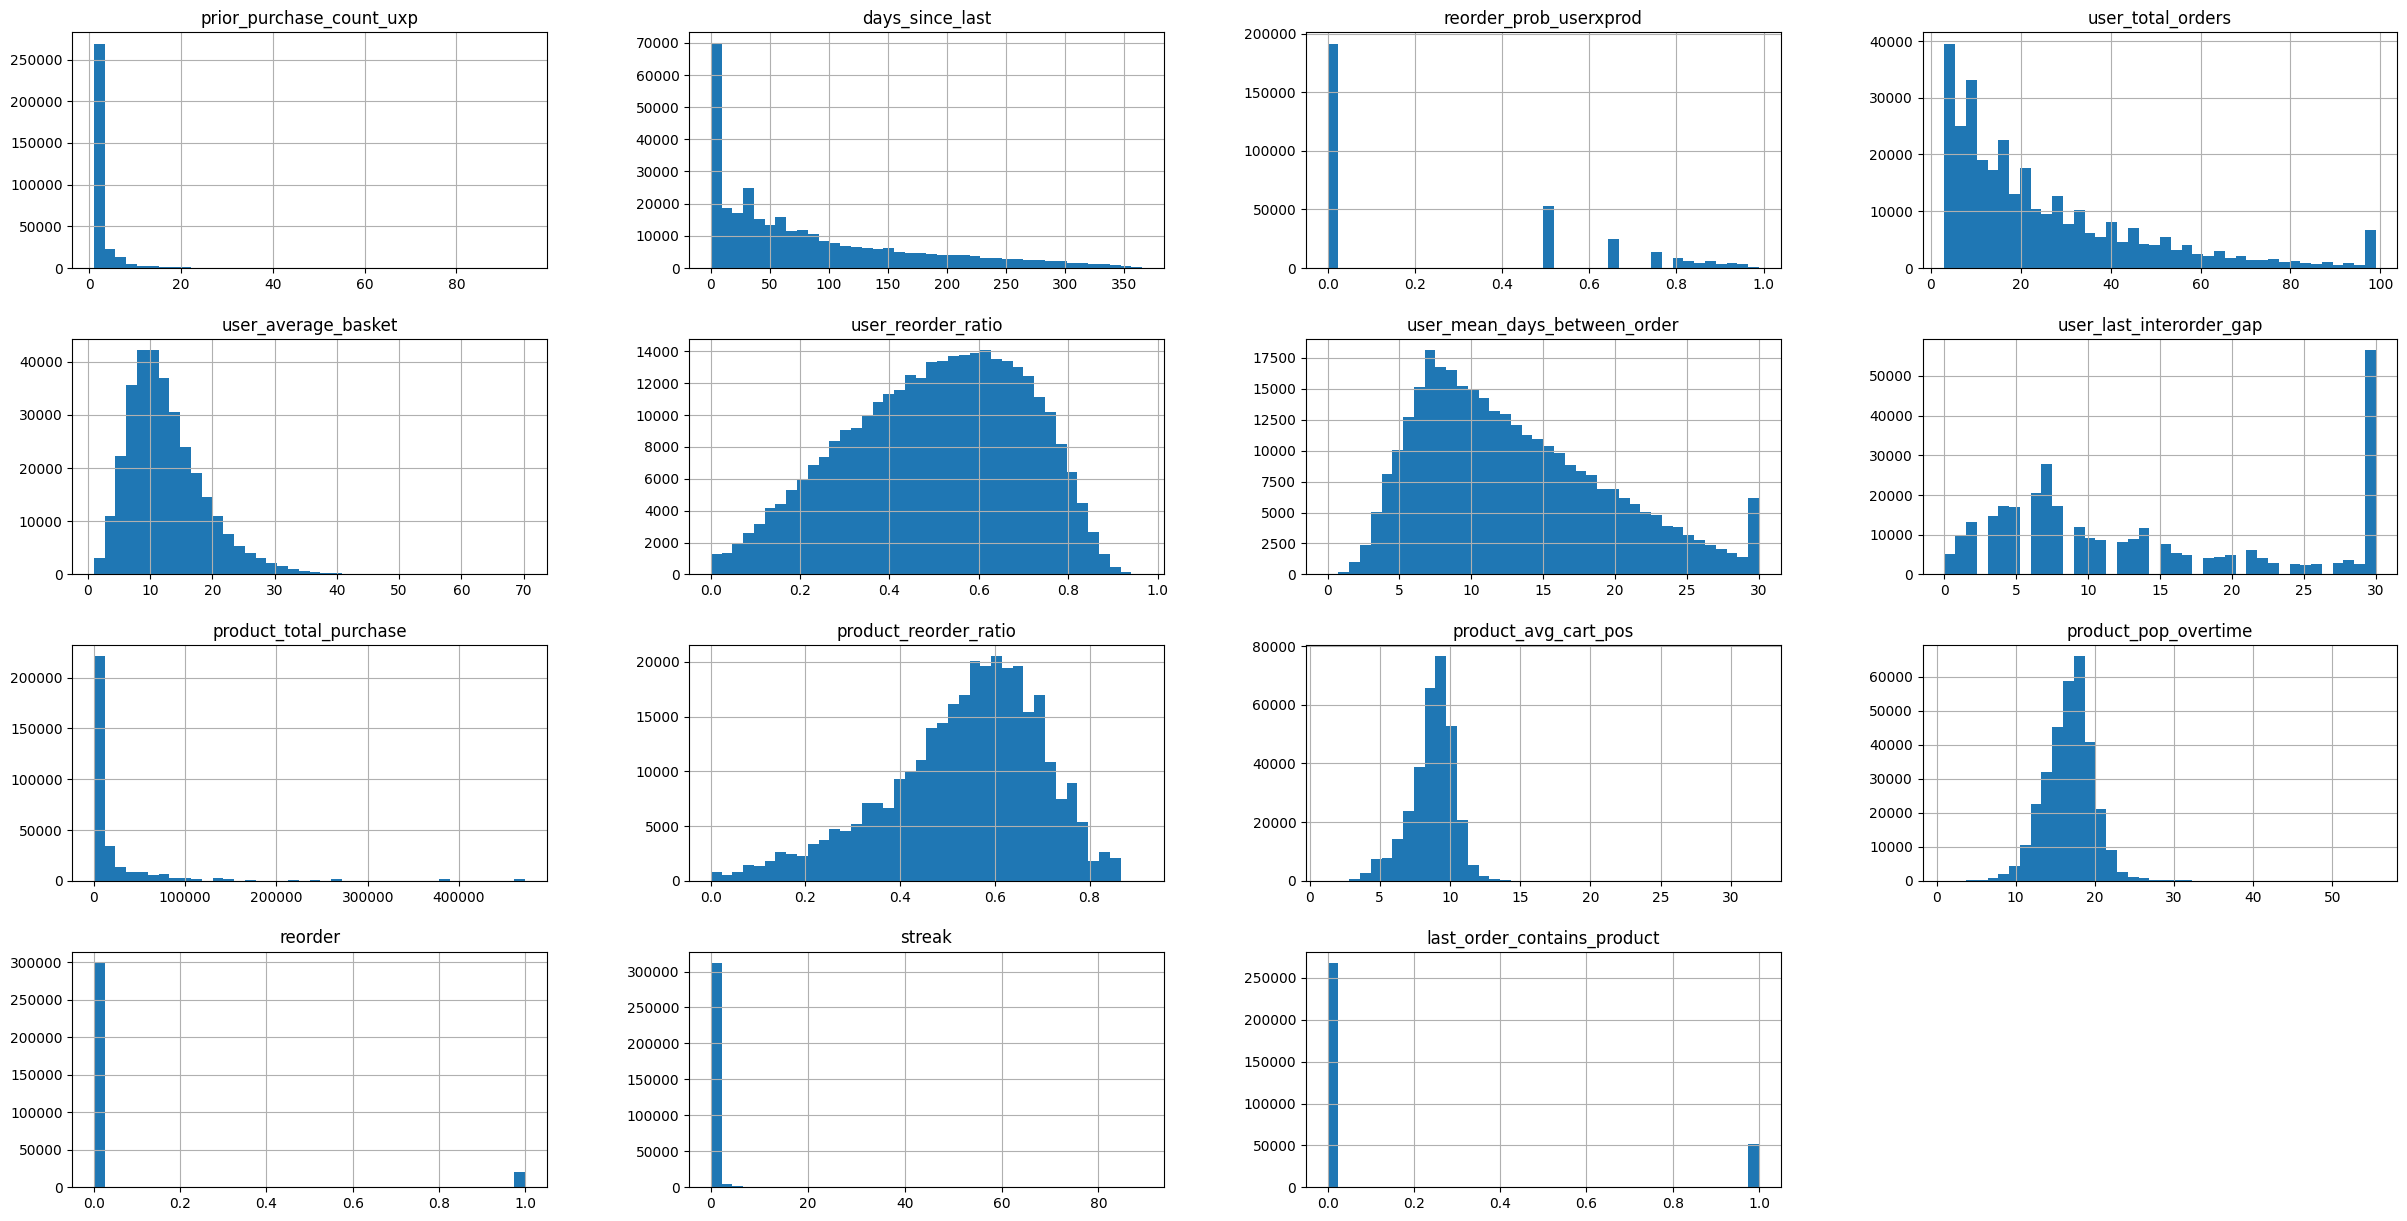

In [ ]:
import matplotlib.pyplot as plt
num_columns = eda_df.iloc[:,2:]
num_columns.hist(bins=40, figsize=(30,15))
plt.show()

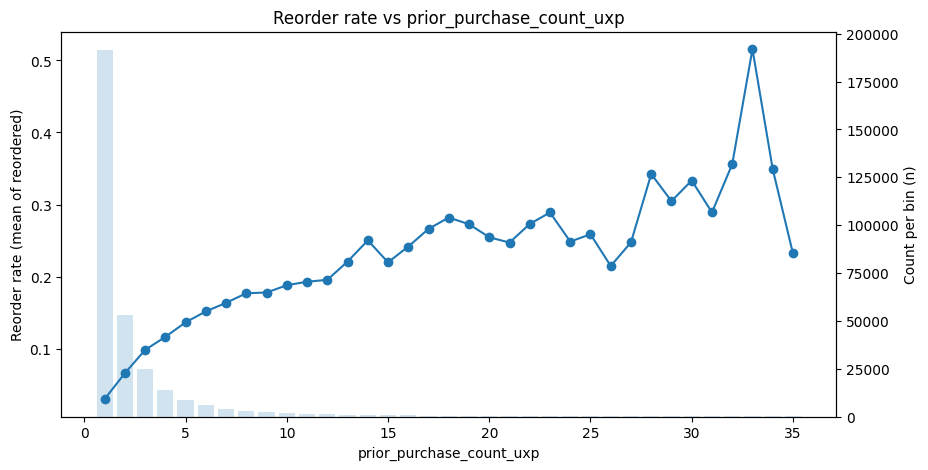

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
col = "prior_purchase_count_uxp"
y = "reorder"

tmp = (
    eda_df
    .groupby(col)[y]
    .agg(rate="mean", n="size")
    .reset_index()
    .sort_values(col)
)

tmp2 = tmp[tmp["n"] >= 50]

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(tmp2[col], tmp2["rate"], marker="o")
ax1.set_title("Reorder rate vs prior_purchase_count_uxp")
ax1.set_xlabel(col)
ax1.set_ylabel("Reorder rate (mean of reordered)")

ax2 = ax1.twinx()
ax2.bar(tmp2[col], tmp2["n"], alpha=0.2)
ax2.set_ylabel("Count per bin (n)")

plt.show()


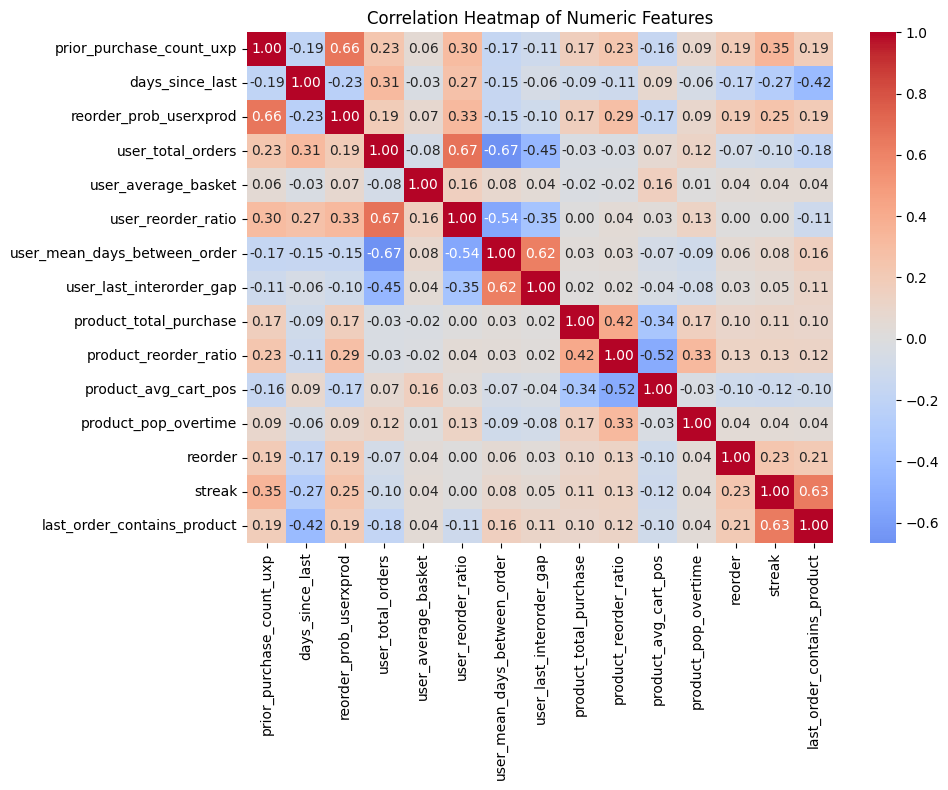

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

corr = eda_df.iloc[:,2:].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

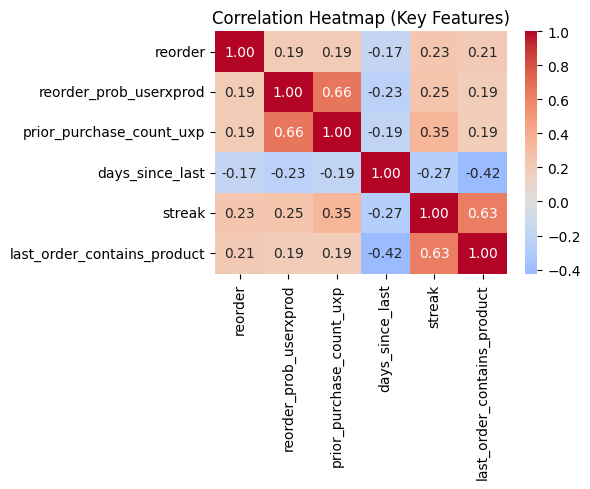

In [ ]:

cols = [
    "reorder",
    "reorder_prob_userxprod",
    "prior_purchase_count_uxp",
    "days_since_last",
    "streak",
    "last_order_contains_product"
]

corr_focus = eda_df[cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_focus,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Key Features)")
plt.tight_layout()
plt.show()

##Train–Test Consistency & Model-Specific Scaling

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
clf_data = pd.read_parquet("/content/drive/MyDrive/instacart_project/data/classification/clf_df.parquet")

In [ ]:
user_label = clf_data.groupby("user_id")["reorder"].max().astype(int)
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

train_users, test_users = train_test_split(
    users,
    test_size=0.2,
    random_state=42,
    stratify=y_user
)
cl_train_df = clf_data[clf_data["user_id"].isin(train_users)].copy()
cl_test_df  = clf_data[clf_data["user_id"].isin(test_users)].copy()

In [ ]:
X_train = cl_train_df.drop(["user_id", "product_id", "reorder"], axis=1)
y_train = cl_train_df["reorder"].astype(int)

X_test = cl_test_df.drop(["user_id", "product_id", "reorder"], axis=1)
y_test = cl_test_df["reorder"].astype(int)


In [ ]:

right_tailed_features = ["prior_purchase_count_uxp", "days_since_last", "product_total_purchase", "streak"]
other_features = ["reorder_prob_userxprod","user_total_orders","user_average_basket", "user_reorder_ratio", "user_mean_days_between_order","user_last_interorder_gap","product_reorder_ratio","product_avg_cart_pos" ,"product_pop_overtime"]
binary_features = ["last_order_contains_product"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
import numpy as np

log_and_scale = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

scale_only = Pipeline([
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("log_features", log_and_scale, right_tailed_features),
    ("normal_features", scale_only, other_features),
    ("binary_features", "passthrough", binary_features)
])


In [ ]:
import pandas as pd

results = []  # list of dicts (one row per model)

def add_result(model_name, y_true, proba, pred, threshold=None, fit_time_sec=None, notes=None):
    from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, brier_score_loss, confusion_matrix

    roc = roc_auc_score(y_true, proba)
    ap  = average_precision_score(y_true, proba)
    f1  = f1_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec  = recall_score(y_true, pred, zero_division=0)
    brier = brier_score_loss(y_true, proba)

    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    results.append({
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc,
        "pr_auc_ap": ap,
        "f1": f1,
        "precision": prec,
        "recall": rec,
        "brier": brier,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "fit_time_sec": fit_time_sec,
        "notes": notes
    })

def results_df():
    return pd.DataFrame(results).sort_values("pr_auc_ap", ascending=False)


In [ ]:
RESULTS_PATH = "/content/drive/MyDrive/instacart_project/results/model_comparison.csv"
results_df = pd.read_csv(RESULTS_PATH)
results_df

,model,threshold,roc_auc,pr_auc_ap,f1,precision,recall,brier,tp,fp,tn,fn,fit_time_sec,notes
0,LightGBM,0.159008,0.818675,0.262963,0.334271,0.270046,0.438579,0.051427,72815,196824,2302954,93210,155.977606,NaN
1,LogisticRegression,0.160000,0.813474,0.254598,0.327417,0.270227,0.415311,0.051823,68952,186211,2313567,97073,152.950883,NaN
2,Dicision Tree,0.745000,0.813537,0.253276,0.328371,0.264347,0.433320,0.178000,71942,200208,2299570,94083,219.250675,NaN


##Logistic Regression (with L1/L2, class weights)

Detailed Logistic Regression development, cross-validation, threshold tuning, and intermediate analyses are provided in the following notebook:

👉 [Step-by-step Logistic Regression development notebook](../notebooks/step_by_step_Logistic_Reg_classification_tsk.ipynb)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_final_lr = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="saga",
        penalty="l2",
        C=1.0,
        max_iter=2000,
        n_jobs=-1,
        random_state=42
    ))
])

THRESHOLD = 0.16


In [ ]:
import time

start = time.time()
pipe_final_lr.fit(X_train, y_train)
fit_time = time.time() - start



In [ ]:
proba_test = pipe_final_lr.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= THRESHOLD).astype(int)


In [ ]:
add_result(
    "LogisticRegression",
    y_test,
    proba_test,
    pred_test,
    threshold=THRESHOLD,
    fit_time_sec=fit_time
)


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/instacart_project/results", exist_ok=True)

results_df().to_csv(
    "/content/drive/MyDrive/instacart_project/results/model_comparison.csv",
    index=False
)
print("Saved: model_comparison.csv")

Saved: model_comparison.csv


In [ ]:
import os, joblib
os.makedirs("/content/drive/MyDrive/instacart_project/models", exist_ok=True)
joblib.dump(pipe_final_lr, "/content/drive/MyDrive/instacart_project/models/lr_final.joblib")
print("Saved fitted models to Drive")

Saved fitted models to Drive


In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

print("TEST ROC-AUC:", roc_auc_score(y_test, proba_test))
print("TEST AP     :", average_precision_score(y_test, proba_test))

print("\nClassification report:\n")
print(classification_report(y_test, pred_test, digits=4))


TEST ROC-AUC: 0.813473673879497
TEST AP     : 0.2545975726960639

Classification report:

              precision    recall  f1-score   support

           0     0.9597    0.9255    0.9423   2499778
           1     0.2702    0.4153    0.3274    166025

    accuracy                         0.8937   2665803
   macro avg     0.6150    0.6704    0.6349   2665803
weighted avg     0.9168    0.8937    0.9040   2665803



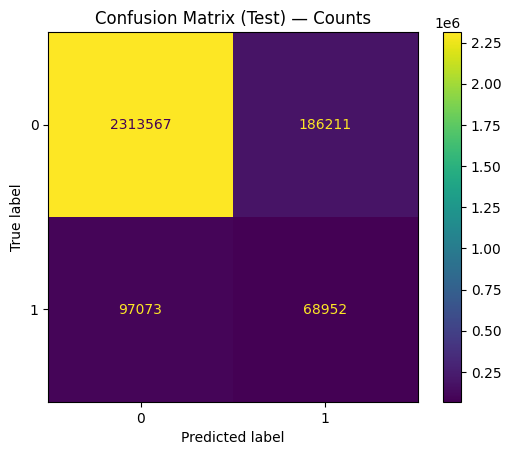

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test) — Counts")
plt.show()


This confusion matrix summarizes the final Logistic Regression model’s predictions on the held-out Instacart test set (2,665,803 user–product observations) using the fixed decision threshold 0.16.

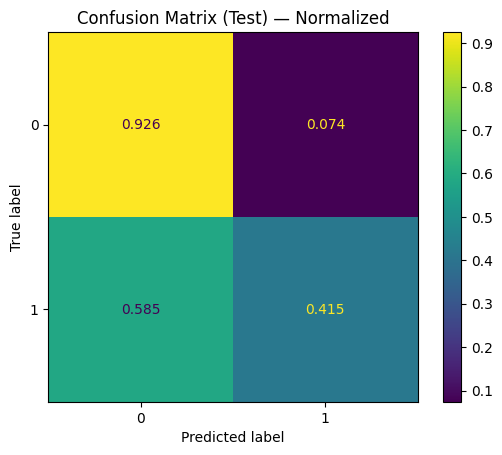

In [ ]:
cm_norm = confusion_matrix(y_test, pred_test, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=[0, 1])
disp.plot(values_format=".3f")
plt.title("Confusion Matrix (Test) — Normalized")
plt.show()


At the selected threshold (0.16), the model correctly identifies 41.5% of reorder events while maintaining a false positive rate of 7.4% among non-reorders.

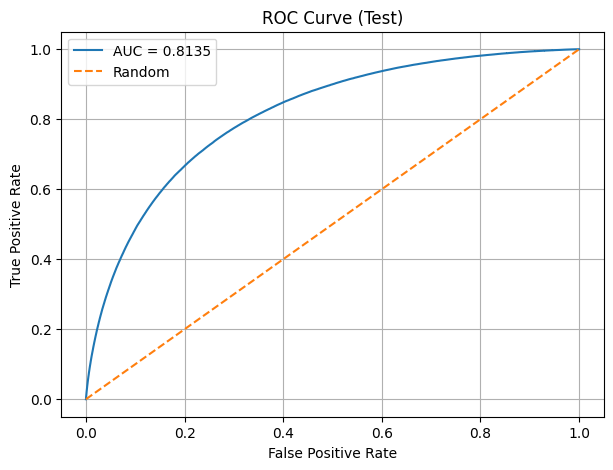

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, proba_test)
auc = roc_auc_score(y_test, proba_test)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.grid(True)
plt.show()


The ROC curve on the test set shows strong ranking performance, with an AUC of 0.813, indicating effective separation between reordered and non-reordered items

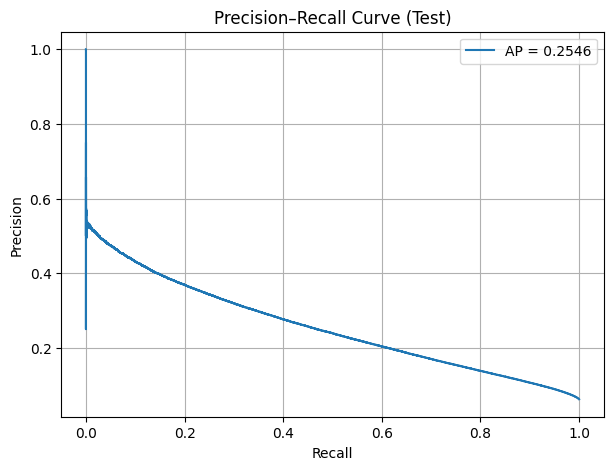

In [ ]:
from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

plt.figure(figsize=(7,5))
plt.plot(rec, prec, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test)")
plt.legend()
plt.grid(True)
plt.show()


The Precision–Recall curve yields an Average Precision of 0.255, substantially higher than the 6.2% reorder baseline, confirming meaningful predictive signal in an imbalanced setting.

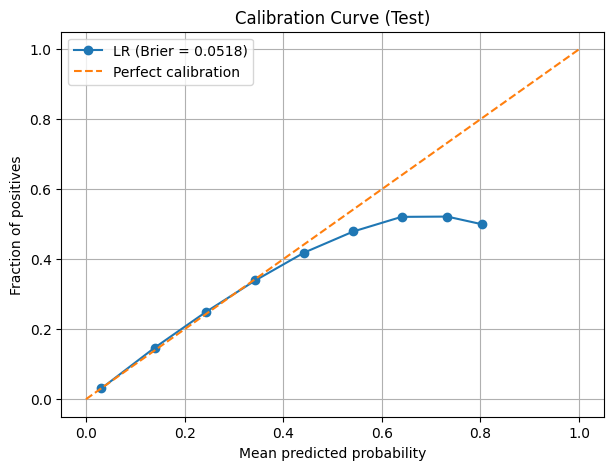

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_test, proba_test, n_bins=10, strategy="uniform"
)
brier = brier_score_loss(y_test, proba_test)

plt.figure(figsize=(7,5))
plt.plot(prob_pred, prob_true, marker="o",
         label=f"LR (Brier = {brier:.4f})")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve (Test)")
plt.legend()
plt.grid(True)
plt.show()


The calibration curve indicates good alignment between predicted probabilities and observed reorder frequencies, with mild overconfidence at higher probability ranges.

The final Logistic Regression model was evaluated on a held-out test set with a reorder rate of approximately 6.2%, reflecting a highly imbalanced prediction task. Despite this imbalance, the model demonstrates strong ranking performance, achieving a ROC-AUC of 0.813 and an Average Precision of 0.255, substantially outperforming a random baseline. Using the fixed decision threshold of 0.16 selected on the training set, the model correctly identifies approximately 41.5% of reorder events while maintaining a relatively low false positive rate among non-reorders. These results indicate that the model captures meaningful reorder signal and provides a stable, interpretable baseline for comparison with more complex models.

##Gradient boosting classifier (LightGBM)

Detailed LightGBM development, cross-validation strategy, threshold tuning, and interpretability analysis are provided in the following notebook:
👉 [Step-by-step LightGBM development notebook](../notebooks/step_by_step_LightGBM_classification_tsk.ipynb)


In [ ]:
import lightgbm as lgb

best_n_estimators = 105
best_threshold = 0.15900837813819962

final_light = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=best_n_estimators,
    random_state=42,
    n_jobs=2
)

In [ ]:
import time

start = time.time()
final_light.fit(X_train, y_train)
fit_time = time.time() - start

[LightGBM] [Info] Number of positive: 662799, number of negative: 9979351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.175534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2322
[LightGBM] [Info] Number of data points in the train set: 10642150, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.062281 -> initscore=-2.711802
[LightGBM] [Info] Start training from score -2.711802


In [ ]:
test_proba = final_light.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= best_threshold).astype(int)

print("Predicted positive rate:", test_pred.mean())

Predicted positive rate: 0.10114738410902831


In [ ]:
add_result(
    "LightGBM",
    y_test,
    test_proba,
    test_pred,
    threshold=best_threshold,
    fit_time_sec=fit_time
)

In [ ]:
import os
os.makedirs("/content/drive/MyDrive/instacart_project/results", exist_ok=True)

results_df().to_csv(
    "/content/drive/MyDrive/instacart_project/results/model_comparison.csv",
    index=False
)
print("Saved: model_comparison.csv")

Saved: model_comparison.csv


In [ ]:
import os, joblib
os.makedirs("/content/drive/MyDrive/instacart_project/models", exist_ok=True)

joblib.dump(final_light, "/content/drive/MyDrive/instacart_project/models/lgbm_final.joblib")
print("Saved fitted models to Drive")

Saved fitted models to Drive


In [ ]:
df = results_df()
display(df)

,model,threshold,roc_auc,pr_auc_ap,f1,precision,recall,brier,tp,fp,tn,fn,fit_time_sec,notes
1,LightGBM,0.159008,0.818675,0.262963,0.334271,0.270046,0.438579,0.051427,72815,196824,2302954,93210,155.977606,None
0,LogisticRegression,0.160000,0.813474,0.254598,0.327417,0.270227,0.415311,0.051823,68952,186211,2313567,97073,152.950883,None


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print("Test AUC:", roc_auc_score(y_test, test_proba))
print("Test AP :", average_precision_score(y_test, test_proba))
print("Test F1 :", f1_score(y_test, test_pred))

Test AUC: 0.8186749729492528
Test AP : 0.26296310097182546
Test F1 : 0.3342713650886922


All plots are generated using the final model trained on the full training set and evaluated on the held-out test set.

<Figure size 500x500 with 0 Axes>

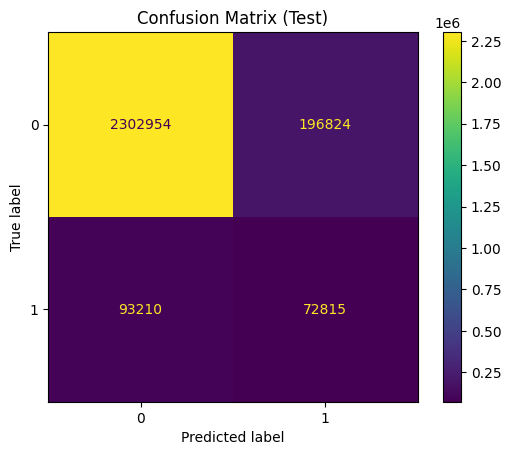

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(5,5))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()


The confusion matrix summarizes prediction outcomes at the selected decision threshold, illustrating the trade-off between capturing reorders and limiting false positives.

<Figure size 500x500 with 0 Axes>

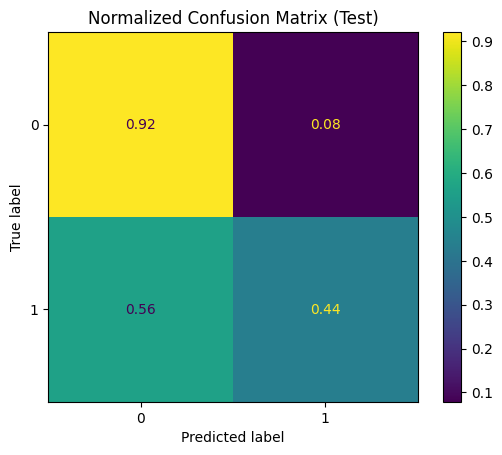

In [ ]:
cmn = confusion_matrix(y_test, test_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cmn)

plt.figure(figsize=(5,5))
disp.plot(values_format=".2f")
plt.title("Normalized Confusion Matrix (Test)")
plt.show()

The normalized confusion matrix shows that the model correctly identifies a large proportion of non-reorders while capturing a meaningful share of reorders.

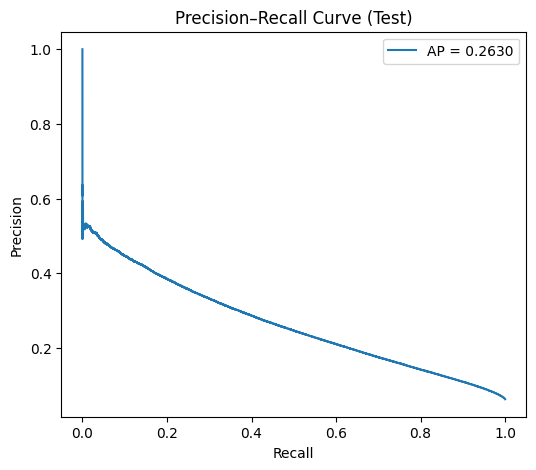

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test)")
plt.legend()
plt.show()

The Precision–Recall curve highlights the model’s ability to identify reorders under class imbalance, achieving an Average Precision of approximately 0.26.

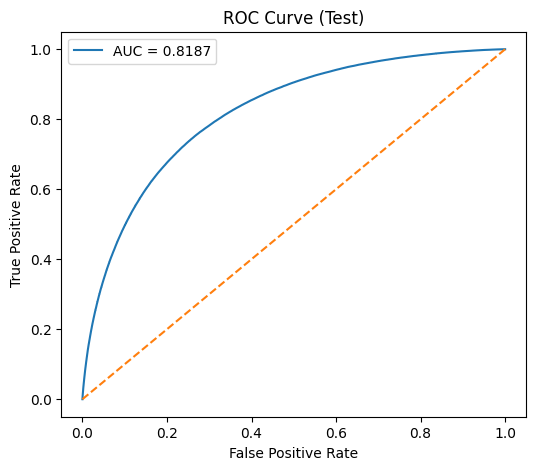

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_proba)
auc = roc_auc_score(y_test, test_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

The ROC curve shows strong class separation on the test set, with an AUC of approximately 0.82, indicating effective ranking of reorder and non-reorder instances.

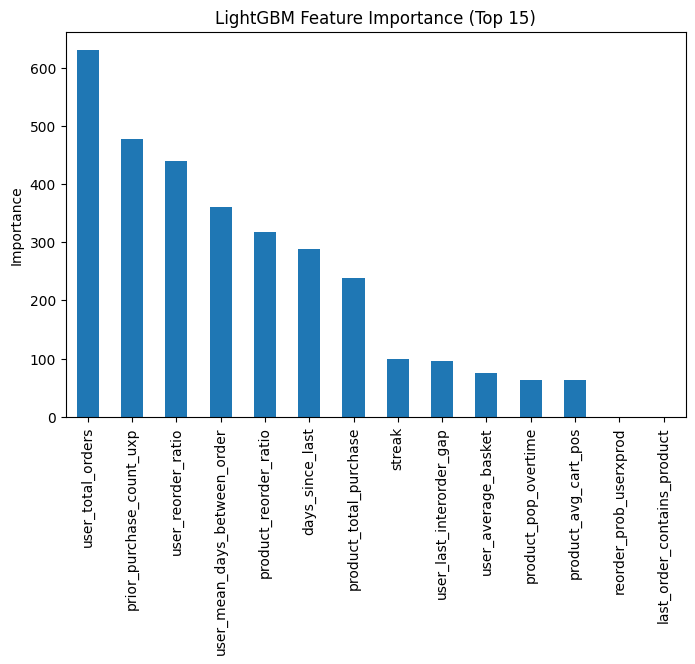

In [ ]:
import pandas as pd

imp = pd.Series(final_light.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
imp.head(15).plot(kind="bar")
plt.title("LightGBM Feature Importance (Top 15)")
plt.ylabel("Importance")
plt.show()

The feature importance plot highlights the most influential features used by the model, with user activity and recency-based features contributing most to predictions.

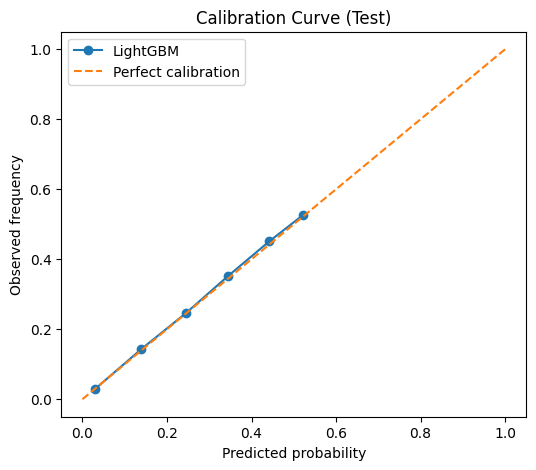

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test, test_proba, n_bins=10, strategy="uniform"
)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="LightGBM")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve (Test)")
plt.legend()
plt.show()

The calibration curve indicates that predicted probabilities are reasonably well aligned with observed reorder frequencies on the test set.

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(final_light)

In [ ]:
X_shap = X_test.sample(10000, random_state=42)
shap_values = explainer.shap_values(X_shap)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


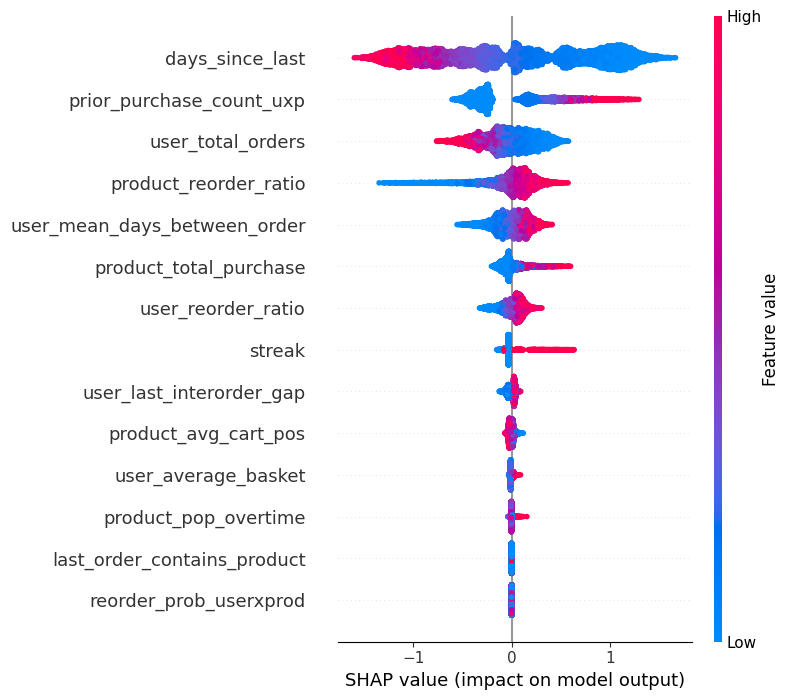

In [ ]:
shap.summary_plot(shap_values, X_shap)

The SHAP summary plot provides a global explanation of the model, showing both the importance and direction of feature effects on reorder predictions.

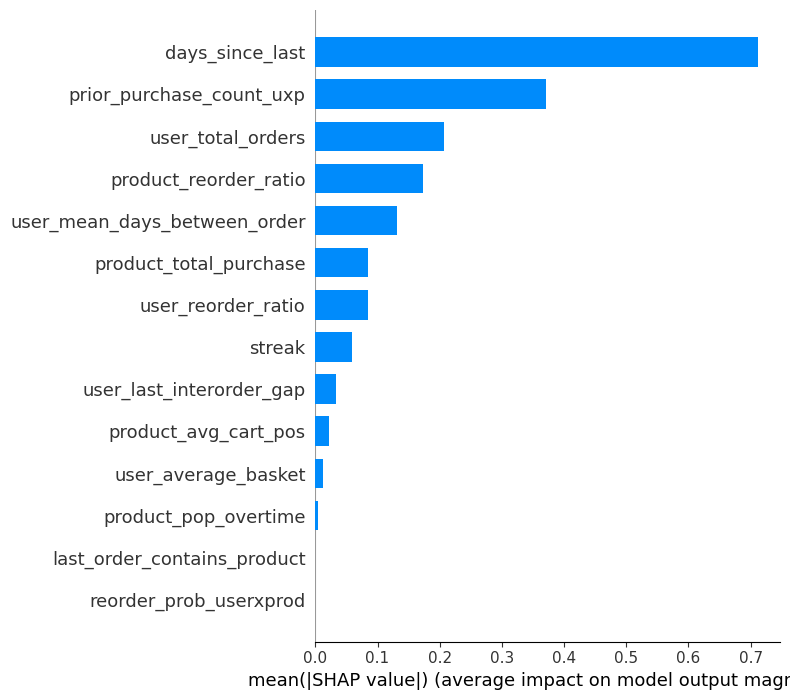

In [ ]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

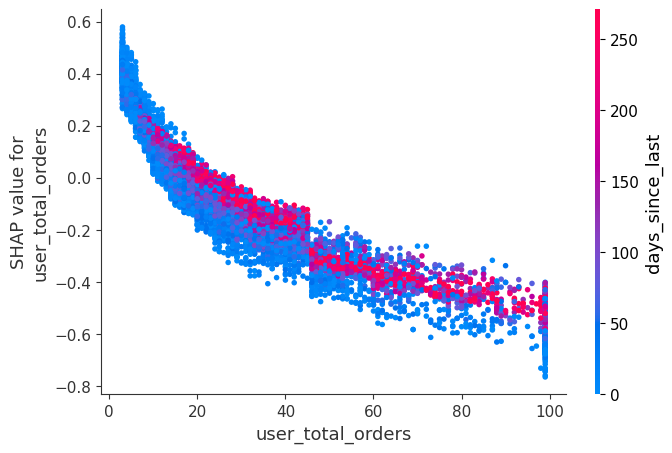

In [ ]:
shap.dependence_plot(
    "user_total_orders",
    shap_values,
    X_shap
)


The SHAP dependence plot illustrates the non-linear relationship between a key feature and the model output, revealing interaction effects with other features.

---

LightGBM achieves slightly higher performance than Logistic Regression across all evaluation metrics; however, the numerical improvements are modest. This indicates that the engineered features already provide strong linear separability, allowing Logistic Regression to perform competitively. LightGBM nevertheless offers consistent gains by modeling non-linear relationships and feature interactions, as confirmed by SHAP analysis, at the cost of increased model complexity.

Final Model Comparison (Logistic vs LightGBM)

Logistic Regression provides a strong and competitive baseline, achieving solid performance due to the quality of the engineered features. LightGBM marginally outperforms Logistic Regression across all evaluation metrics, including ROC-AUC and Average Precision. Although the numerical improvements are small, LightGBM consistently demonstrates better ranking performance by capturing non-linear relationships and feature interactions, as confirmed through SHAP analysis. This highlights a trade-off between model simplicity and predictive power, where LightGBM offers modest but reliable gains at the cost of increased complexity.

⚠️ Limitations

Despite strong overall performance, the improvement of LightGBM over Logistic Regression is limited, suggesting that much of the predictive signal is already captured through linear relationships. Additionally, due to computational constraints, hyperparameter tuning and early stopping analysis were conducted on a representative sample rather than the full training dataset. While this approach is standard practice, it may slightly limit the achievable performance ceiling.

🧠 One-line takeaway

Overall, the results demonstrate that strong feature engineering enables simple models to perform competitively, while more complex models provide incremental gains through non-linear modeling.

##Decision Tree classifier

Detailed Decision Tree development, including baseline modeling, regularization, and GroupKFold evaluation, is documented in the following notebook:👉 [Decision Tree development notebook](../notebooks/step_by_step_Decision_Tree_classification_tsk.ipynb)

In [ ]:

from sklearn.tree import DecisionTreeClassifier

dt_final = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=9,
    min_samples_leaf=200,
    min_samples_split=2
)
thr_dt = 0.745


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
import time

start = time.time()
dt_final.fit(X_train, y_train)
fit_time = time.time() - start

test_scores_dt = dt_final.predict_proba(X_test)[:, 1]

print("DT TEST AUC:", roc_auc_score(y_test, test_scores_dt))
print("DT TEST AP :", average_precision_score(y_test, test_scores_dt))

DT TEST AUC: 0.8135368408547836
DT TEST AP : 0.2532762991417745


In [ ]:
from sklearn.metrics import f1_score

test_pred_dt = (test_scores_dt >= thr_dt).astype(int)

print("DT TEST F1 (OOF threshold):", f1_score(y_test, test_pred_dt))

DT TEST F1 (OOF threshold): 0.32837108461231246


In [ ]:
add_result(
    "Dicision Tree",
    y_test,
    test_scores_dt,
    test_pred_dt,
    threshold=thr_dt,
    fit_time_sec=fit_time
)

In [ ]:
import os
os.makedirs("/content/drive/MyDrive/instacart_project/results", exist_ok=True)

results_df().to_csv(
    "/content/drive/MyDrive/instacart_project/results/model_comparison.csv",
    index=False
)
print("Saved: model_comparison.csv")

Saved: model_comparison.csv


In [ ]:
df = results_df()
display(df)

,model,threshold,roc_auc,pr_auc_ap,f1,precision,recall,brier,tp,fp,tn,fn,fit_time_sec,notes
1,LightGBM,0.159008,0.818675,0.262963,0.334271,0.270046,0.438579,0.051427,72815,196824,2302954,93210,155.977606,None
0,LogisticRegression,0.160000,0.813474,0.254598,0.327417,0.270227,0.415311,0.051823,68952,186211,2313567,97073,152.950883,None
2,Dicision Tree,0.745000,0.813537,0.253276,0.328371,0.264347,0.433320,0.178000,71942,200208,2299570,94083,219.250675,None


In [ ]:
import os, joblib
os.makedirs("/content/drive/MyDrive/instacart_project/models", exist_ok=True)
joblib.dump(dt_final, "/content/drive/MyDrive/instacart_project/models/dt_final.joblib")
print("Saved fitted models to Drive")


Saved fitted models to Drive


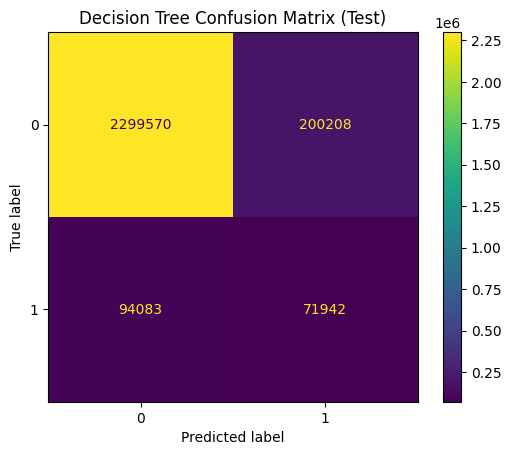

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix (Test)")
plt.show()

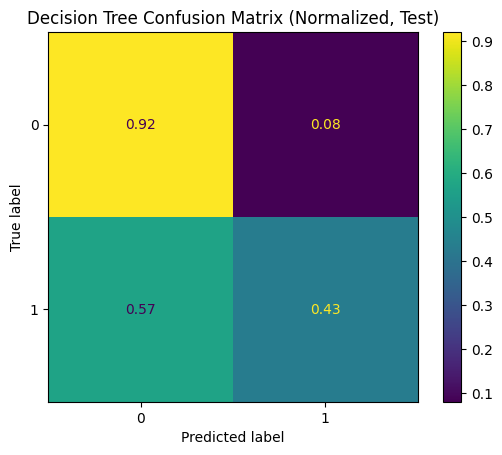

In [ ]:
cm_norm = confusion_matrix(y_test, test_pred_dt, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(values_format=".2f")
plt.title("Decision Tree Confusion Matrix (Normalized, Test)")
plt.show()

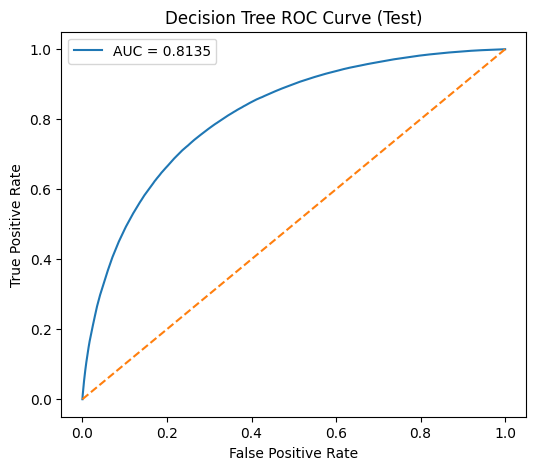

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_scores_dt)
auc = roc_auc_score(y_test, test_scores_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve (Test)")
plt.legend()
plt.show()


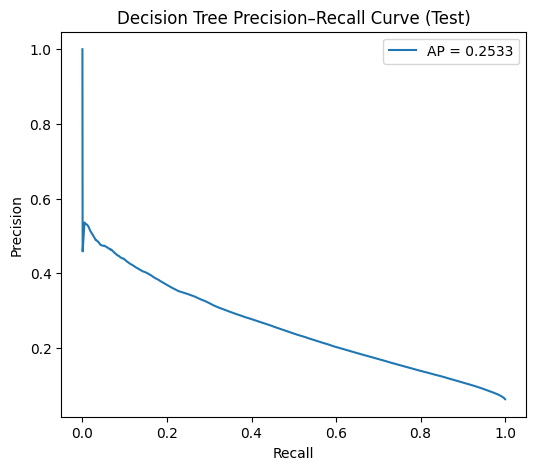

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, test_scores_dt)
ap = average_precision_score(y_test, test_scores_dt)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree Precision–Recall Curve (Test)")
plt.legend()
plt.show()

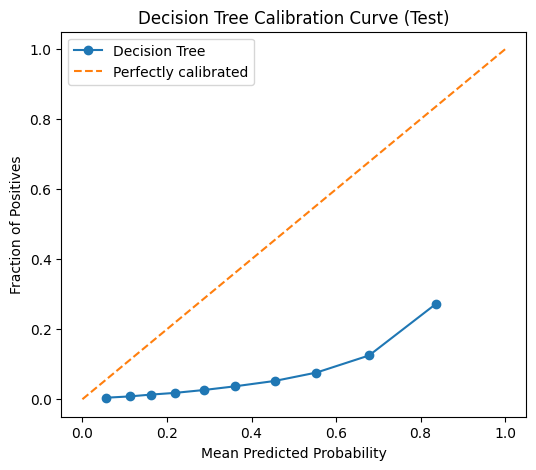

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_scores_dt, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="Decision Tree")
plt.plot([0,1], [0,1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Decision Tree Calibration Curve (Test)")
plt.legend()
plt.show()


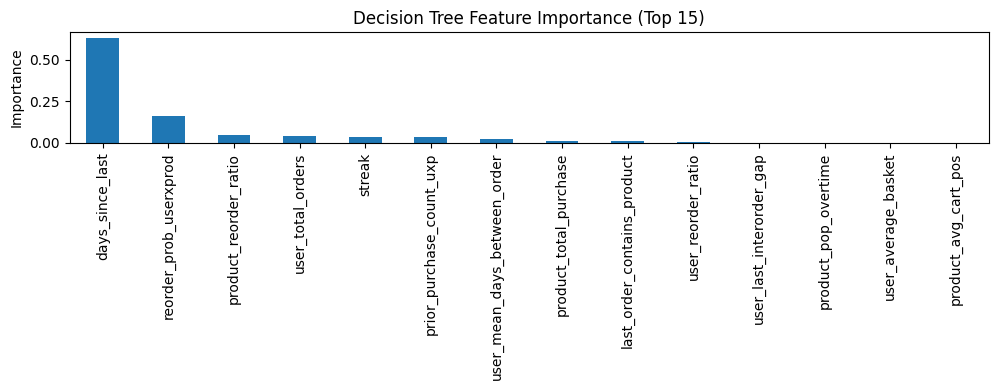

In [ ]:
import pandas as pd

imp = pd.Series(dt_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
topk = imp.head(15)

ax = topk.plot(kind="bar", figsize=(10,4))
plt.title("Decision Tree Feature Importance (Top 15)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

##Random Forest

Random forset Tree development, including baseline modeling, regularization, and GroupKFold evaluation, is documented in the following notebook:👉 [random forset development notebook](../notebooks/step_by_step_Random_Forest_classification_tsk.ipynb)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=200
)

thr_rf = 0.1653

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
import time

start = time.time()
rf_final.fit(X_train, y_train)
fit_time = time.time() - start



In [ ]:
test_scores_rf = rf_final.predict_proba(X_test)[:, 1]

print("RF TEST AUC:", roc_auc_score(y_test, test_scores_rf))
print("RF TEST AP :", average_precision_score(y_test, test_scores_rf))

RF TEST AUC: 0.8185783636909348
RF TEST AP : 0.26339619602768716


In [ ]:
from sklearn.metrics import f1_score
test_pred_rf = (test_scores_rf >= thr_rf).astype(int)

print("RF TEST F1 (OOF threshold):", f1_score(y_test, test_pred_rf))

RF TEST F1 (OOF threshold): 0.3349892233229978


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    brier_score_loss,
    confusion_matrix
)


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
)
new_row = {
    "model": "Random Forest",
    "threshold": thr_rf,
    "roc_auc": roc_auc_score(y_test, test_scores_rf),
    "pr_auc_ap": average_precision_score(y_test, test_scores_rf),
    "f1": f1_score(y_test, test_pred_rf),
    "precision": precision_score(y_test, test_pred_rf, zero_division=0),
    "recall": recall_score(y_test, test_pred_rf),
    "brier": brier_score_loss(y_test, test_scores_rf),
    "fit_time_sec": fit_time
}

tn, fp, fn, tp = confusion_matrix(y_test, test_pred_rf).ravel()
new_row.update({"tp": tp, "fp": fp, "tn": tn, "fn": fn})


In [ ]:
results_df = pd.concat(
    [results_df, pd.DataFrame([new_row])],
    ignore_index=True
)

results_df.to_csv(RESULTS_PATH, index=False)
print("Saved to Drive ✅")

Saved to Drive ✅


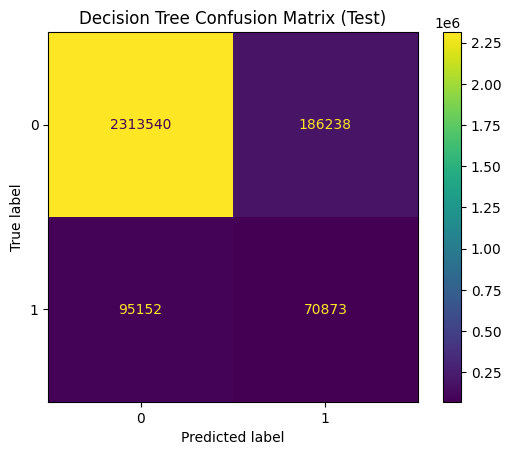

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, test_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix (Test)")
plt.show()

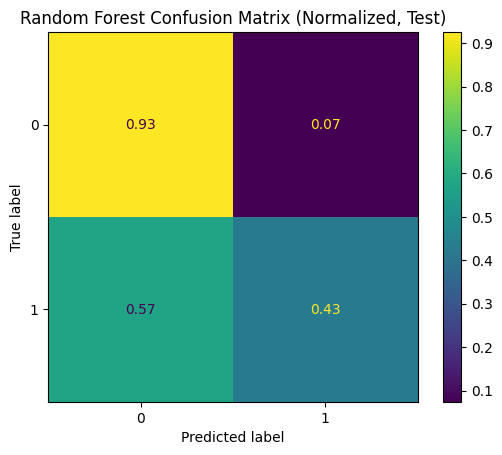

In [ ]:
cm_norm = confusion_matrix(y_test, test_pred_rf, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(values_format=".2f")
plt.title("Random Forest Confusion Matrix (Normalized, Test)")
plt.show()

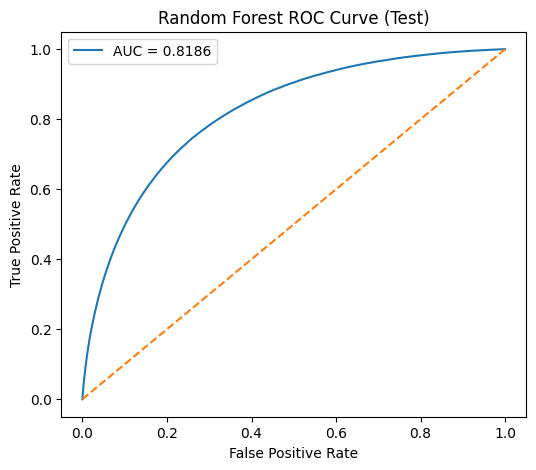

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_scores_rf)
auc = roc_auc_score(y_test, test_scores_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve (Test)")
plt.legend()
plt.show()


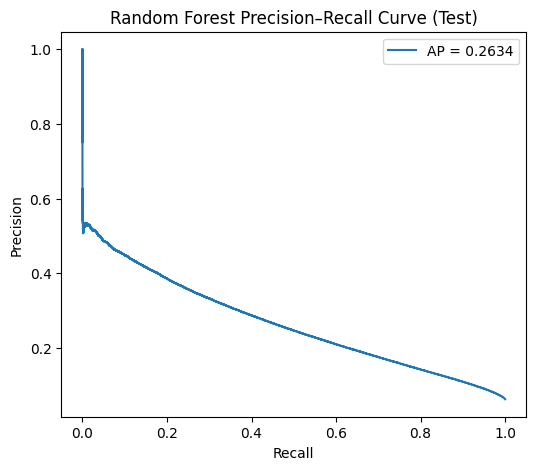

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, test_scores_rf)
ap = average_precision_score(y_test, test_scores_rf)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision–Recall Curve (Test)")
plt.legend()
plt.show()

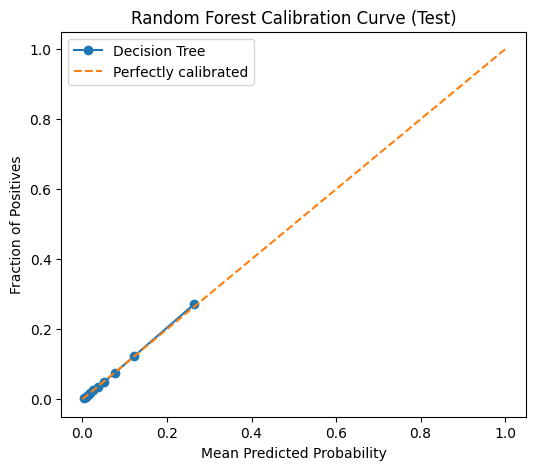

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_scores_rf, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="Decision Tree")
plt.plot([0,1], [0,1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Random Forest Calibration Curve (Test)")
plt.legend()
plt.show()

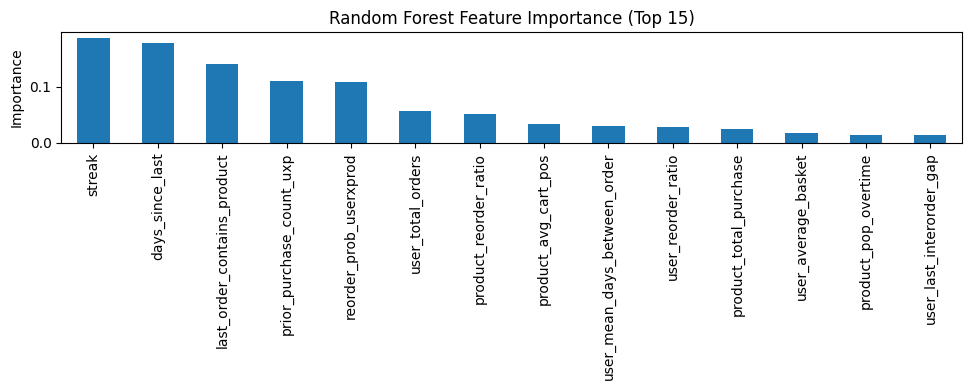

In [ ]:
import pandas as pd

imp = pd.Series(rf_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
topk = imp.head(15)

ax = topk.plot(kind="bar", figsize=(10,4))
plt.title("Random Forest Feature Importance (Top 15)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

##KNN

A detailed implementation, exploratory analysis,PLots and experimental evaluation of the K-Nearest Neighbors (KNN).👉 [KNN](../notebooks/step_by_step_KNN_classification_tsk.ipynb)

KNN was not fitted on the full dataset nor included in the final results table, as it failed to scale even on a reduced sample due to its lazy learning nature—requiring distance computations against the entire training set at prediction time—making it computationally infeasible for this dataset.

##SVM

The full experimental workflow, including implementation details and preliminary evaluations for both the linear and RBF kernel variants, is provided in the corresponding Google Colab notebooks for reference.👉 [SVM](../notebooks/step_by_step_SVM_classification_tsk.ipynb)

Additional model variants (linear and RBF kernel) were explored; however, as they failed to outperform the primary models and incurred substantially higher computational cost, they were excluded from the final comparison to maintain a focused and efficient evaluation.

##model_comparison

In [ ]:
import pandas as pd

RESULTS_PATH = "/content/drive/MyDrive/instacart_project/results/model_comparison.csv"
df = pd.read_csv(RESULTS_PATH)

# Optional: sort by PR-AUC (AP)
df = df.sort_values("pr_auc_ap", ascending=False).reset_index(drop=True)
df

,model,threshold,roc_auc,pr_auc_ap,f1,precision,recall,brier,tp,fp,tn,fn,fit_time_sec,notes
0,Random Forest,0.165300,0.818578,0.263396,0.334989,0.275651,0.426881,0.051421,70873,186238,2313540,95152,2727.845820,NaN
1,LightGBM,0.159008,0.818675,0.262963,0.334271,0.270046,0.438579,0.051427,72815,196824,2302954,93210,155.977606,NaN
2,LogisticRegression,0.160000,0.813474,0.254598,0.327417,0.270227,0.415311,0.051823,68952,186211,2313567,97073,152.950883,NaN
3,Dicision Tree,0.745000,0.813537,0.253276,0.328371,0.264347,0.433320,0.178000,71942,200208,2299570,94083,219.250675,NaN


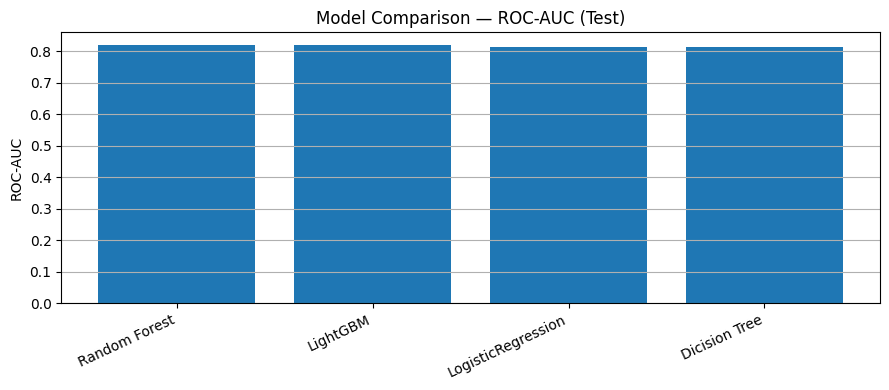

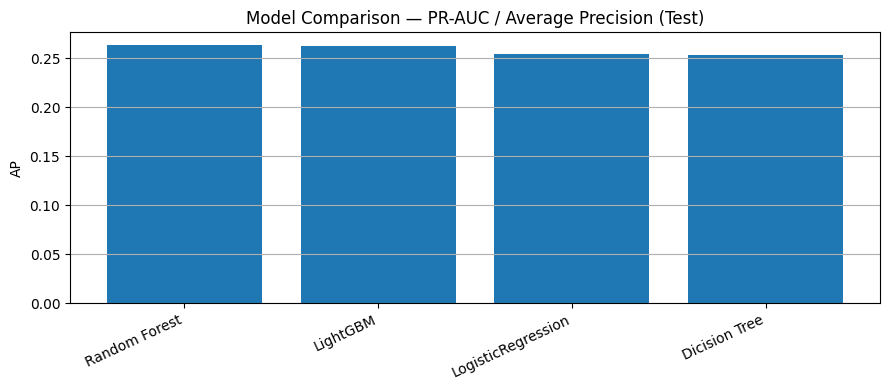

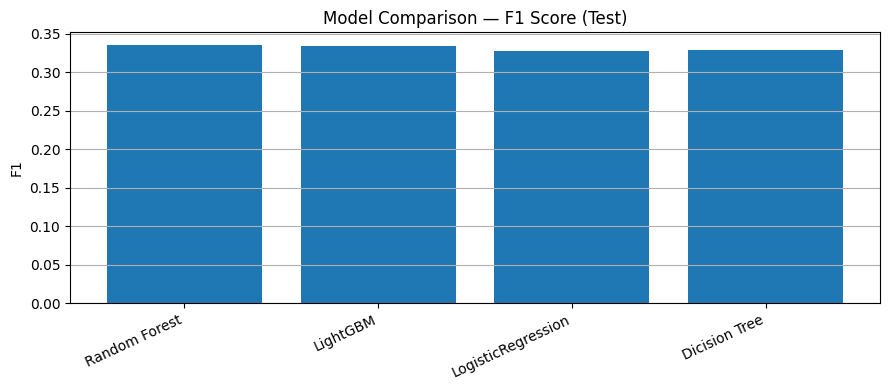

In [ ]:
import matplotlib.pyplot as plt

def bar_plot(metric, title, ylabel=None):
    plt.figure(figsize=(9,4))
    plt.bar(df["model"], df[metric])
    plt.xticks(rotation=25, ha="right")
    plt.title(title)
    plt.ylabel(ylabel or metric)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

bar_plot("roc_auc",   "Model Comparison — ROC-AUC (Test)", "ROC-AUC")
bar_plot("pr_auc_ap", "Model Comparison — PR-AUC / Average Precision (Test)", "AP")
bar_plot("f1",        "Model Comparison — F1 Score (Test)", "F1")

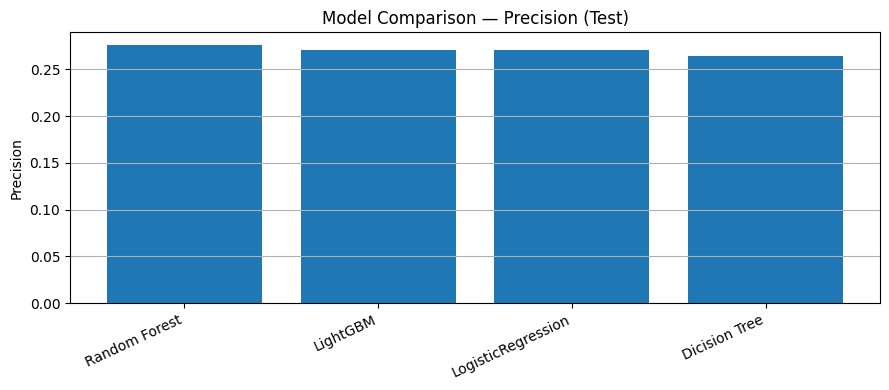

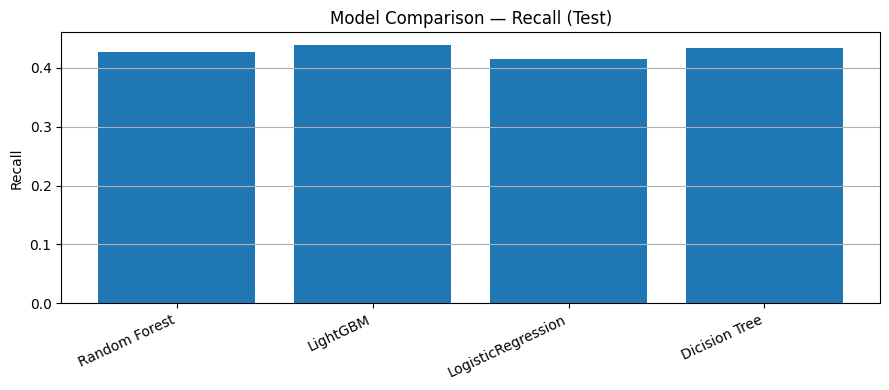

In [ ]:
bar_plot("precision", "Model Comparison — Precision (Test)", "Precision")
bar_plot("recall",    "Model Comparison — Recall (Test)", "Recall")


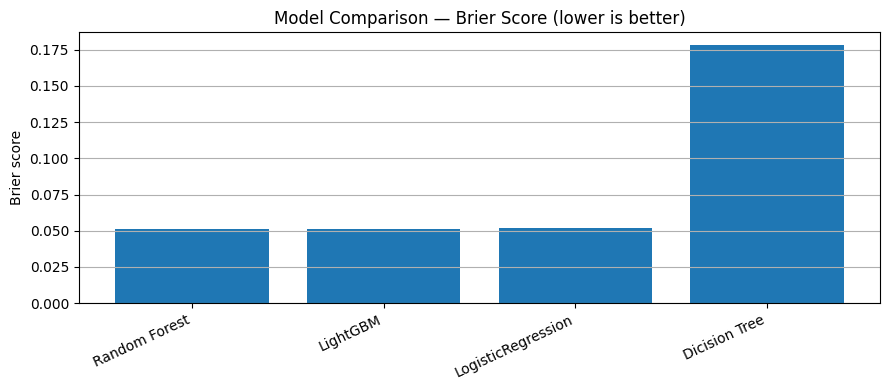

In [ ]:
bar_plot("brier", "Model Comparison — Brier Score (lower is better)", "Brier score")


The higher Brier score of the Decision Tree reflects its tendency to produce overconfident probability estimates, a known limitation of single-tree models.

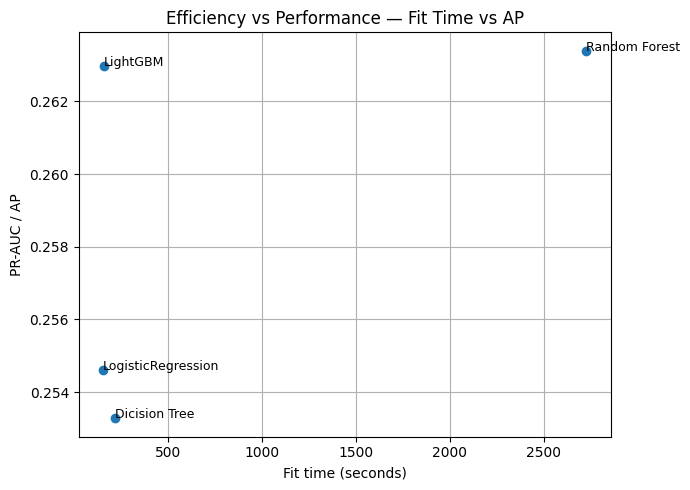

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df["fit_time_sec"], df["pr_auc_ap"])
for i, row in df.iterrows():
    plt.annotate(row["model"], (row["fit_time_sec"], row["pr_auc_ap"]), fontsize=9)

plt.xlabel("Fit time (seconds)")
plt.ylabel("PR-AUC / AP")
plt.title("Efficiency vs Performance — Fit Time vs AP")
plt.grid(True)
plt.tight_layout()
plt.show()


# Task-B-Regression

Based on all the previous information and features, the most suitable Target to work on is predicting the number of days until the user's next order (days_until_next_order).

In [ ]:
import pandas as pd

We work on an orders table (which contains the order of user requests and the time between requests)

In [ ]:
orders = datasets["orders"].copy()


In [ ]:
orders = orders.sort_values(["user_id", "order_number"])
orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0


 The main idea:
days_since_prior_order in the current row = how many days have passed since the "previous order"

 We need a target = how many days until the "next order"
So we get the days_since_prior_order for the next order and put it with the current order

In [ ]:
orders["days_to_next_order"] = orders.groupby("user_id")["days_since_prior_order"].shift(-1)
orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,days_to_next_order
0,2539329,1,prior,1,2,8,NaN,15.0
1,2398795,1,prior,2,3,7,15.0,21.0
2,473747,1,prior,3,3,12,21.0,29.0
3,2254736,1,prior,4,4,7,29.0,28.0
4,431534,1,prior,5,4,15,28.0,19.0
...,...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0,30.0
3421079,1854736,206209,prior,11,4,10,30.0,18.0
3421080,626363,206209,prior,12,1,12,18.0,7.0
3421081,2977660,206209,prior,13,1,12,7.0,30.0


 We define the snapshot (the last prior order for each user)

Why? Because my features are built from prior_full (i.e., from the prior date)

So we make the prediction point the last prior order, and the target is the interval for the next order

In [ ]:
prior_snapshot = (orders[orders["eval_set"] == "prior"].groupby("user_id", as_index=False).tail(1)[["user_id", "order_id", "order_number", "days_to_next_order"]])
prior_snapshot

,user_id,order_id,order_number,days_to_next_order
9,1,2550362,10,14.0
24,2,839880,14,30.0
37,3,1402502,12,11.0
43,4,2557754,5,30.0
48,5,157374,4,6.0
...,...,...,...,...
3420932,206205,414137,3,10.0
3421000,206206,1904200,67,0.0
3421017,206207,1005822,16,14.0
3421067,206208,1882108,49,4.0


I merged the snapshot with the user_features we created earlier.

Each row at the end = one user (this is what's required in Task-B).

In [ ]:
task_B_df = prior_snapshot.merge(user_features, on="user_id", how="left")
task_B_df

,user_id,order_id,order_number,days_to_next_order,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap
0,1,2550362,10,14.0,10,5.900000,0.694915,20.259260,30.0
1,2,839880,14,30.0,14,13.928571,0.476923,15.967033,13.0
2,3,1402502,12,11.0,12,7.333333,0.625000,11.487180,15.0
3,4,2557754,5,30.0,5,3.600000,0.055556,15.357142,0.0
4,5,157374,4,6.0,4,9.250000,0.378378,14.500000,19.0
...,...,...,...,...,...,...,...,...,...
206204,206205,414137,3,10.0,3,10.666667,0.250000,20.666666,10.0
206205,206206,1904200,67,0.0,67,4.253731,0.473684,4.042705,11.0
206206,206207,1005822,16,14.0,16,13.937500,0.587444,14.879397,18.0
206207,206208,1882108,49,4.0,49,13.816327,0.707533,7.442105,7.0


saving the df to google drive

In [ ]:
project_dir = "/content/drive/MyDrive/instacart_project"
data_dir = f"{project_dir}/regression_data"

os.makedirs(data_dir, exist_ok=True)


project_dir = "/content/drive/MyDrive/instacart_project"
save_path = f"{project_dir}/regression_data/task_B_df.parquet"

task_B_df.to_parquet(save_path, compression="snappy")
print("Saved:", save_path)


Saved: /content/drive/MyDrive/instacart_project/regression_data/task_B_df.parquet


In [ ]:
task_B_df = pd.read_parquet(
   "/content/drive/MyDrive/instacart_project/regression_data/task_B_df.parquet"
)

## EDA for Regression df

In [ ]:
task_B_df.shape

(206209, 9)

In [ ]:
task_B_df.columns

Index(['user_id', 'order_id', 'order_number', 'days_to_next_order',
       'user_total_orders', 'user_average_basket', 'user_reorder_ratio',
       'user_mean_days_between_order', 'user_last_interorder_gap'],
      dtype='object')

In [ ]:
task_B_df.duplicated().sum()

np.int64(0)

In [ ]:
task_B_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206209 entries, 0 to 206208
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       206209 non-null  int32  
 1   order_id                      206209 non-null  int32  
 2   order_number                  206209 non-null  int16  
 3   days_to_next_order            206209 non-null  float32
 4   user_total_orders             206209 non-null  int16  
 5   user_average_basket           206209 non-null  float64
 6   user_reorder_ratio            206209 non-null  float64
 7   user_mean_days_between_order  206209 non-null  float32
 8   user_last_interorder_gap      206209 non-null  float32
dtypes: float32(3), float64(2), int16(2), int32(2)
memory usage: 7.9 MB


In [ ]:
task_B_df.describe()

,user_id,order_id,order_number,days_to_next_order,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap
count,206209.000000,2.062090e+05,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,1.714464e+06,15.590367,17.061783,15.590367,9.951586,0.432249,15.469670,16.081413
std,59527.555167,9.862824e+05,16.654774,10.672453,16.654774,5.863570,0.212144,7.207112,10.435066
min,1.000000,2.500000e+01,3.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000
25%,51553.000000,8.620630e+05,5.000000,7.000000,5.000000,5.740741,0.267857,9.553798,7.000000
50%,103105.000000,1.713984e+06,9.000000,15.000000,9.000000,8.933333,0.428571,14.692307,14.000000
75%,154657.000000,2.568239e+06,19.000000,30.000000,19.000000,13.000000,0.595745,20.724409,30.000000
max,206209.000000,3.421073e+06,99.000000,30.000000,99.000000,70.250000,0.989529,30.000000,30.000000


In [ ]:
task_B_df.isna().sum()

,0
user_id,0
order_id,0
order_number,0
days_to_next_order,0
user_total_orders,0
user_average_basket,0
user_reorder_ratio,0
user_mean_days_between_order,0
user_last_interorder_gap,0


##Splitting my Data Frame

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
users = task_B_df["user_id"].unique()
users

array([     1,      2,      3, ..., 206207, 206208, 206209], dtype=int32)

In [ ]:
train_users, test_users = train_test_split(users, test_size=0.2, random_state=42)

train_df = task_B_df[task_B_df["user_id"].isin(train_users)].copy()
test_df = task_B_df[task_B_df["user_id"].isin(test_users)].copy()

assert set(train_df["user_id"]).isdisjoint(set(test_df["user_id"]))


In [ ]:
train_df.value_counts().sum()

np.int64(164967)

In [ ]:
test_df.value_counts().sum()

np.int64(41242)

##EDA for train_df

In [ ]:
train_missing = train_df.isnull().sum()
train_missing

,0
user_id,0
order_id,0
order_number,0
days_to_next_order,0
user_total_orders,0
user_average_basket,0
user_reorder_ratio,0
user_mean_days_between_order,0
user_last_interorder_gap,0


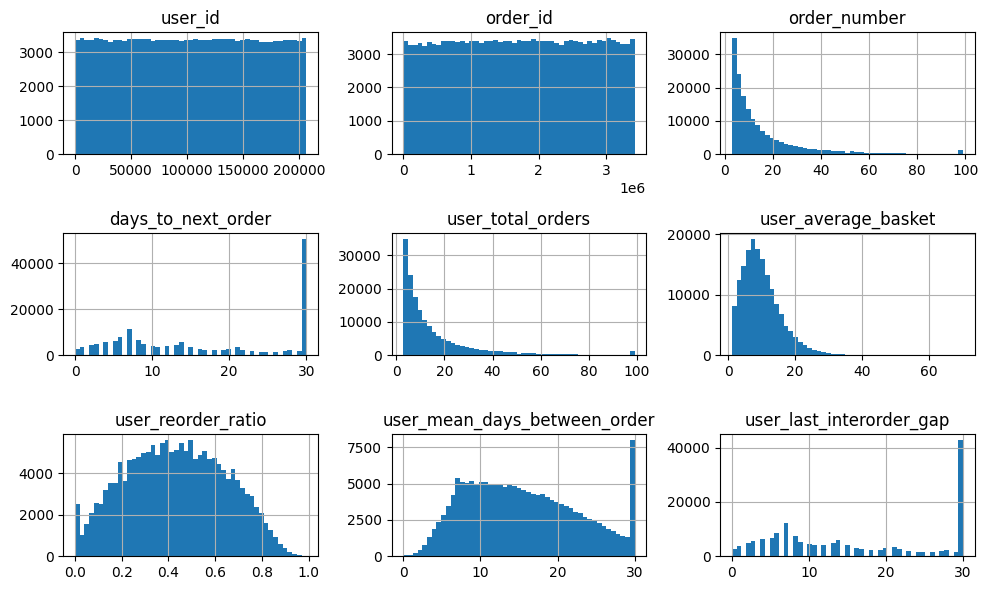

In [ ]:
numeric = train_df.select_dtypes(include=["number"]).columns
train_df[numeric].hist(bins=49, figsize=(10, 6))
plt.tight_layout()
plt.show()

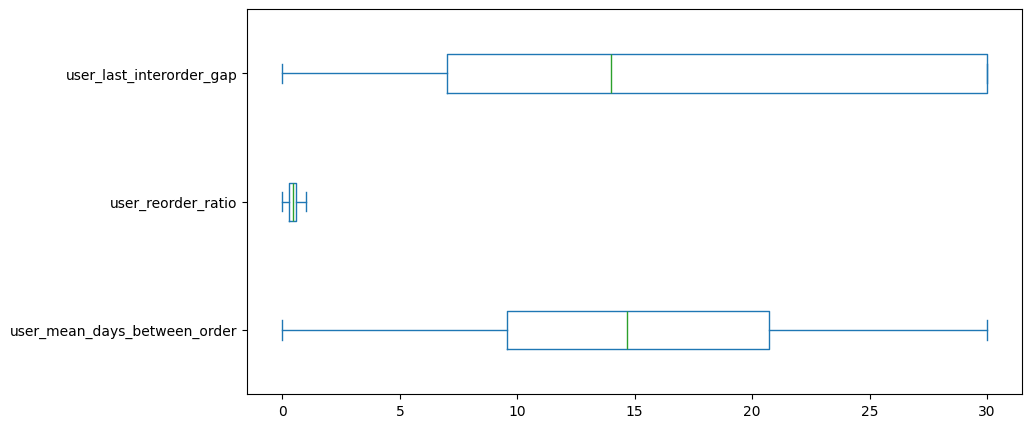

In [ ]:
train_df[['user_mean_days_between_order', 'user_reorder_ratio', 'user_last_interorder_gap']].plot(kind='box', figsize=(10, 5), vert=False)
plt.show()

I want to share some details I've gathered about the drawing below .

If you notice, I was working on the days_to_next_order target.

The distribution turned out to be right-skewed, with a mass point at 30, and the distribution wasn't continuous and smooth, which wasn't our goal at all.

Okay, so what effect does this have on Regression?

✅ The most suitable model for it is (Tree / Boosting)

I will prove that with code later. ^-^



What does each part of the boxplot represent?

1️⃣ The orange line (Medium) ≈ 15 days.

2️⃣ Box (Q1 to Q3) Approximately:

    Q1 ≈ 7 days
    Q3 ≈ 30 days

3️⃣ Whiskers

he left side is close to 1 day. The right side has reached 30 days. This means:

    There are very active users (who reorder quickly).

    And many users reach the maximum limit (30 days), meaning they order almost
    every month.

4️⃣ There are no “outliers”. Why?

Because:

    The value 30 is not a statistical outlier. It is a frequently occurring value

    The IQR is wide due to the distribution itself

Meaning:

    30 is a “normal” value in the data, not an outlier
    This confirms what I said earlier.

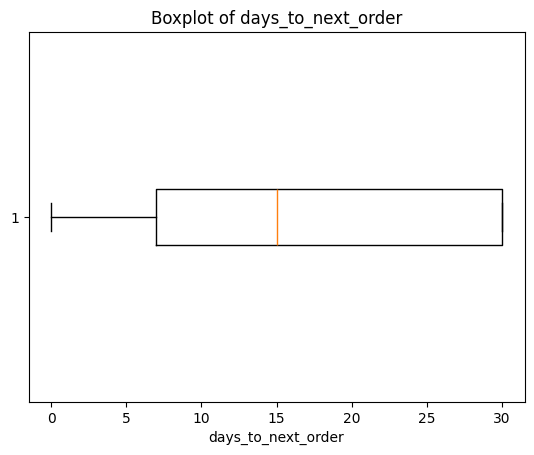

In [ ]:
target = "days_to_next_order"
plt.figure()
plt.boxplot(train_df[target], vert=False)
plt.title("Boxplot of days_to_next_order")
plt.xlabel("days_to_next_order")
plt.show()

Correlation


---


To calculate the correlation, I first identified the numerical columns and excluded three columns (days_to_next_order , user_id , order_id).

**I have excluded the ID columns because they are not important for correlation, and the days_to_next_order column because it is not a feature, it is a target.



In [ ]:
numeric_cols = train_df.select_dtypes(include=["number"]).columns.drop(["days_to_next_order","user_id", "order_id"])
corr =train_df[numeric_cols].corr()
corr

,order_number,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap
order_number,1.000000,1.000000,0.021094,0.636397,-0.540583,-0.373805
user_total_orders,1.000000,1.000000,0.021094,0.636397,-0.540583,-0.373805
user_average_basket,0.021094,0.021094,1.000000,0.110807,-0.018740,-0.022446
user_reorder_ratio,0.636397,0.636397,0.110807,1.000000,-0.432028,-0.285235
user_mean_days_between_order,-0.540583,-0.540583,-0.018740,-0.432028,1.000000,0.643772
user_last_interorder_gap,-0.373805,-0.373805,-0.022446,-0.285235,0.643772,1.000000


Dark blue -> Strong positive correlation (+1)

Dark red -> Strong negative correlation (−1)

Light colors -> Weak correlation / close to zero.

The correlation analysis reveals strong multicollinearity between order_number and user_total_orders, indicating redundancy. Temporal features show moderate positive correlation, reflecting consistent ordering behavior, while basket size remains largely independent from ordering frequency.

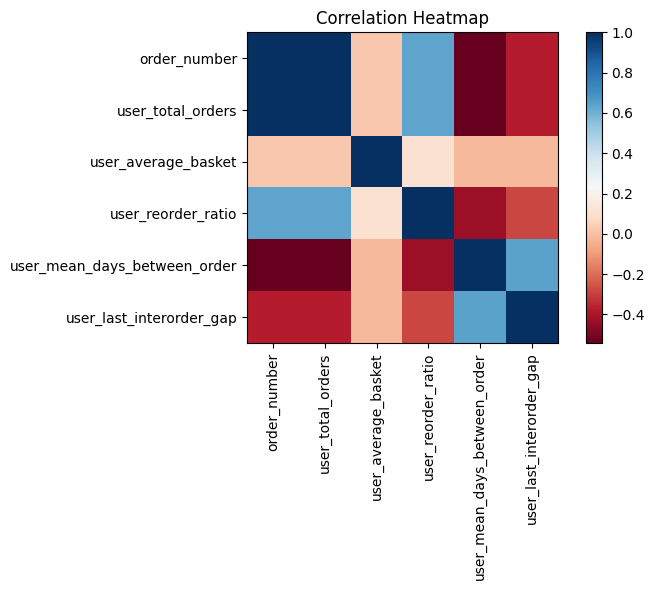

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="RdBu" )
plt.colorbar()
plt.xticks(range(len(numeric_cols)),numeric_cols , rotation=90)
plt.yticks(range(len(numeric_cols)),numeric_cols )
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

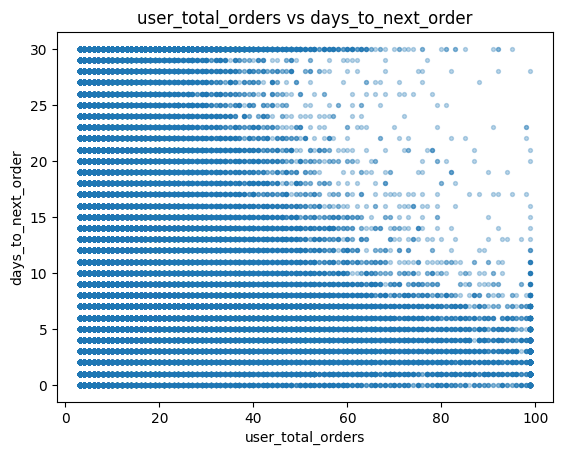

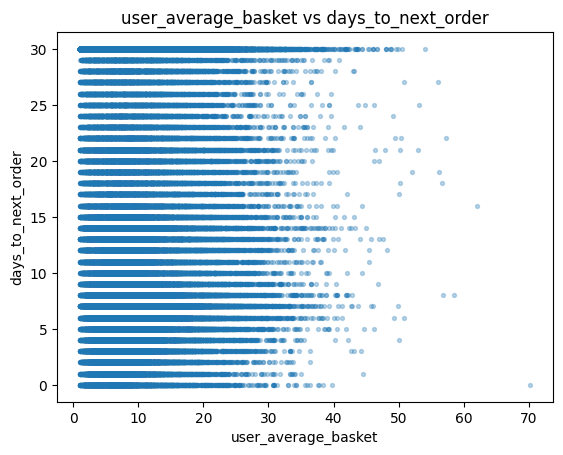

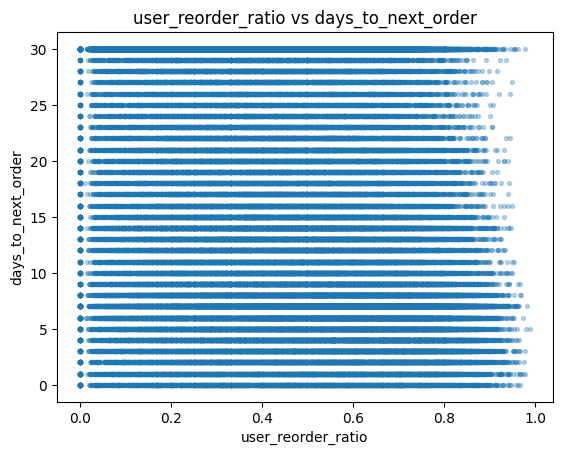

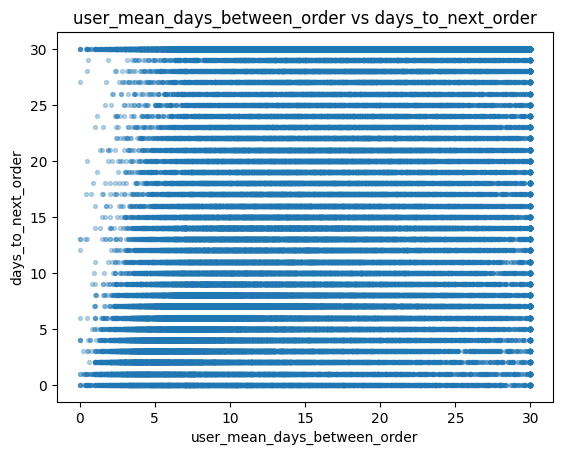

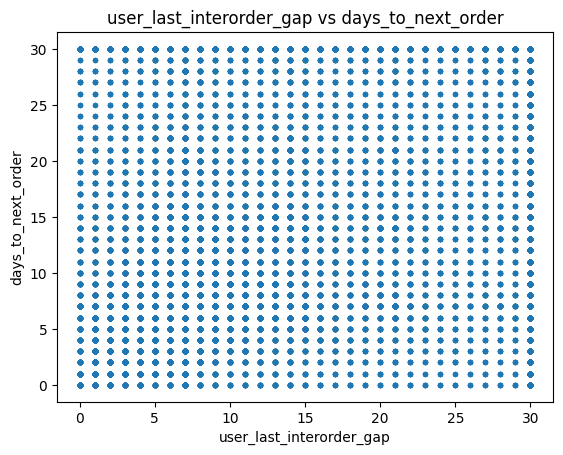

In [ ]:
num_c = [
    c for c in numeric_cols
    if c in train_df.columns and c != "order_number"
]

for col in num_c:
    plt.figure()
    plt.scatter(train_df[col], train_df[target], s=8, alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

##Modeling for Regression Task

There's not much time left to transfer the code as we did in the classification. I'll put the links to my models below.

I previously mentioned that the best option is either (Tree or Boosting), but I will start modeling in the order mentioned in the project file.

####KNN-Regression

A detailed implementation, exploratory analysis,PLots and experimental evaluation of the K-Nearest Neighbors (KNN).👉
[KNN-Regression](../notebooks/Task_B_Boosting.ipynb)

####DecisionTree-Regression


A detailed implementation, exploratory analysis,PLots and experimental evaluation of the DecisionTree .👉[DecisionTree-Regression](../notebooks/Task_B_DecisionTree.ipynb)

####LinearRegression && SVR-Regression

A detailed implementation, exploratory analysis,PLots and experimental evaluation of the LinearRegression.👉 [LinearRegression-Regression](../notebooks/Task_B_LinearRegression.ipynb)

####RandomForest-Regression

A detailed implementation, exploratory analysis,PLots and experimental evaluation of the LinearRegression.👉[RandomForest-Regression](../notebooks/Task_B_RandomForest.ipynb)

####Boosting-Regression

A detailed implementation, exploratory analysis,PLots and experimental evaluation of the LinearRegression.👉[Boosting-Regression](../notebooks/Task_B_Boosting.ipynb)